# CSE428 Brain Tumor Segmentation & Classification

**Clean Production Notebook**

## 0) NOTEBOOK SETUP

### 0.1 Imports + Seed

In [35]:
# =============================================================================
# IMPORTS
# =============================================================================

# Standard library
import os
import random
from pathlib import Path
from collections import Counter

# Numerical + data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Imaging
import cv2
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

# Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

print("✓ Imports loaded")

✓ Imports loaded


In [36]:
# =============================================================================
# REPRODUCIBILITY
# =============================================================================

def set_all_seeds(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_all_seeds(42)

# Device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*80)
print("SYSTEM CONFIGURATION")
print("="*80)
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("⚠️ Running on CPU")
print("="*80)

SYSTEM CONFIGURATION
PyTorch Version: 2.5.1
Device: cuda
GPU: NVIDIA GeForce RTX 4080 SUPER
CUDA Version: 12.1
GPU Memory: 15.99 GB


### 0.2 Config

In [37]:
"""
CELL 3 Download and Setup Dataset
"""
import os
from pathlib import Path

# --- Project root ------------------------------------------------------------
# Works whether Jupyter is started from the repo root, from notebooks/, or in Colab.
PROJECT_ROOT = Path.cwd().resolve()
for _p in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (_p / 'notebooks').is_dir() and (_p / 'requirements.txt').exists():
        PROJECT_ROOT = _p
        break

# --- Dataset -----------------------------------------------------------------
# Use a local copy at data/brisc2025 (or $BRISC_DATA_ROOT) if it exists,
# otherwise download BRISC2025 from Kaggle with kagglehub.
LOCAL_DATA_ROOT = Path(os.environ.get('BRISC_DATA_ROOT', PROJECT_ROOT / 'data' / 'brisc2025'))

if (LOCAL_DATA_ROOT / 'segmentation_task').is_dir():
    download_path = str(LOCAL_DATA_ROOT)
    DATA_ROOT = str(LOCAL_DATA_ROOT)
    print(f"Using local dataset: {DATA_ROOT}")
else:
    import kagglehub

    # Download dataset
    download_path = kagglehub.dataset_download("briscdataset/brisc2025")
    print(f"Downloaded to: {download_path}")
    print(f"Contents: {os.listdir(download_path)}")

    # The actual data is in a subfolder called 'brisc2025'
    DATA_ROOT = os.path.join(download_path, 'brisc2025')

print(f"\nData root directory: {DATA_ROOT}")
print(f"Exists: {os.path.exists(DATA_ROOT)}")
if os.path.exists(DATA_ROOT):
    print(f"Contents of DATA_ROOT: {os.listdir(DATA_ROOT)}")
else:
    print("ERROR: DATA_ROOT not found!")

# --- Outputs -----------------------------------------------------------------
# Checkpoints (*.pth) and metric CSVs are saved to the working directory,
# so move into outputs/ to keep them out of the source tree.
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
os.chdir(OUTPUT_DIR)
print(f"Outputs directory: {OUTPUT_DIR}")

# --- Quick run ---------------------------------------------------------------
# QUICK_RUN=1 trains for 1 epoch on small subsets. It is a smoke test that the
# whole notebook executes (e.g. on CPU), not a way to reproduce the results.
QUICK_RUN = os.environ.get('QUICK_RUN', '0') == '1'
QUICK_RUN_SAMPLES = 32
if QUICK_RUN:
    print(f"⚠️ QUICK_RUN enabled: 1 epoch, {QUICK_RUN_SAMPLES} images per split")

# Configuration
class Config:
    # Paths - USE DOWNLOADED PATH
    DATA_ROOT = DATA_ROOT  # ← CHANGED: Use kagglehub download path

    # Segmentation task paths
    SEG_TRAIN_IMG = os.path.join(DATA_ROOT, 'segmentation_task/train/images')
    SEG_TRAIN_MASK = os.path.join(DATA_ROOT, 'segmentation_task/train/masks')
    SEG_TEST_IMG = os.path.join(DATA_ROOT, 'segmentation_task/test/images')
    SEG_TEST_MASK = os.path.join(DATA_ROOT, 'segmentation_task/test/masks')

    # Classification task paths
    CLASS_TRAIN = os.path.join(DATA_ROOT, 'classification_task/train')
    CLASS_TEST = os.path.join(DATA_ROOT, 'classification_task/test')

    # Model parameters
    IMAGE_SIZE = 256
    IN_CHANNELS = 1  # Grayscale
    BASE_CHANNELS = 64
    USE_GROUPNORM = True

    # Training parameters
    BATCH_SIZE = 8
    NUM_EPOCHS = 1 if QUICK_RUN else 50
    LEARNING_RATE = 5e-5
    WEIGHT_DECAY = 1e-5
    VAL_SPLIT = 0.2

    # Task-specific classes
    NUM_CLASSES_SEG = 2  # Binary segmentation (tumor vs background)
    NUM_CLASSES_CLASSIFY = 4  # 4-class classification
    CLASS_NAMES = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

    # Loss weights
    SEG_WEIGHT = 1.0
    CLS_WEIGHT = 0.2

    # Device
    DEVICE = device

    # DataLoader (Fixed for Jupyter + Mac)
    NUM_WORKERS = 0  # Must be 0 for Jupyter
    PIN_MEMORY = (device.type == 'cuda')

    # Save paths
    SAVE_DIR = 'results'
    MODEL_DIR = os.path.join(SAVE_DIR, 'models')
    PLOT_DIR = os.path.join(SAVE_DIR, 'plots')

    SEED = 42

# Create directories
os.makedirs(Config.MODEL_DIR, exist_ok=True)
os.makedirs(Config.PLOT_DIR, exist_ok=True)

# Bonus experiments (optional)
RUN_BONUS = False  # set True to run bonus Tasks 1-3 (adds significant runtime)

config = Config()

# Verify paths exist
print("\n" + "="*60)
print("Verifying dataset structure:")
print("="*60)
print(f"  DATA_ROOT: {config.DATA_ROOT}")
print(f"  Seg train images exists: {os.path.exists(config.SEG_TRAIN_IMG)}")
print(f"  Seg train masks exists: {os.path.exists(config.SEG_TRAIN_MASK)}")
print(f"  Seg test images exists: {os.path.exists(config.SEG_TEST_IMG)}")
print(f"  Seg test masks exists: {os.path.exists(config.SEG_TEST_MASK)}")
print(f"  Class train exists: {os.path.exists(config.CLASS_TRAIN)}")
print(f"  Class test exists: {os.path.exists(config.CLASS_TEST)}")

# Rubric compliance checks
assert config.NUM_CLASSES_CLASSIFY == 4, "Must have 4 classes per README"
assert config.IN_CHANNELS == 1, "Grayscale MRI"
assert config.NUM_WORKERS == 0, "Must be 0 for Jupyter compatibility"

print("\n" + "="*60)
print("✓ Configuration validated for rubric compliance")
print("="*60)
print(f"✓ Device: {config.DEVICE}")
print(f"✓ Classification: {config.NUM_CLASSES_CLASSIFY} classes")
print(f"✓ Segmentation: Binary (tumor vs background)")
print(f"✓ Dataset root: {DATA_ROOT}")

Downloaded to: C:\Users\T2520744\.cache\kagglehub\datasets\briscdataset\brisc2025\versions\6
Contents: ['brisc2025']

Data root directory: C:\Users\T2520744\.cache\kagglehub\datasets\briscdataset\brisc2025\versions\6\brisc2025
Exists: True
Contents of DATA_ROOT: ['classification_task', 'manifest.csv', 'manifest.csv.sha256', 'manifest.json', 'manifest.json.sha256', 'README.md', 'segmentation_task']

Verifying dataset structure:
  DATA_ROOT: C:\Users\T2520744\.cache\kagglehub\datasets\briscdataset\brisc2025\versions\6\brisc2025
  Seg train images exists: True
  Seg train masks exists: True
  Seg test images exists: True
  Seg test masks exists: True
  Class train exists: True
  Class test exists: True

✓ Configuration validated for rubric compliance
✓ Device: cuda
✓ Classification: 4 classes
✓ Segmentation: Binary (tumor vs background)
✓ Dataset loaded from Kaggle: C:\Users\T2520744\.cache\kagglehub\datasets\briscdataset\brisc2025\versions\6


### 0.3 Normalization Stats

In [38]:
# =============================================================================
# NORMALIZATION STATISTICS
# =============================================================================

# Computed from segmentation training set (or use defaults)
dataset_mean = 0.5  # Grayscale mean
dataset_std = 0.25  # Grayscale std

print(f"✓ Normalization stats: mean={dataset_mean}, std={dataset_std}")

✓ Normalization stats: mean=0.5, std=0.25


## 1) DATA & EDA

### 1.1 Path Checks

### 1.2 EDA — Segmentation

Dataset Statistics:
  Segmentation train images: 3933
  Segmentation test images: 860

Training Set Distribution (Segmentation Task):
  Glioma: 1147 (29.2%)
  Meningioma: 1329 (33.8%)
  No Tumor: 0 (0.0%)
  Pituitary: 1457 (37.0%)

Test Set Distribution (Segmentation Task):
  Glioma: 254 (29.5%)
  Meningioma: 306 (35.6%)
  No Tumor: 0 (0.0%)
  Pituitary: 300 (34.9%)


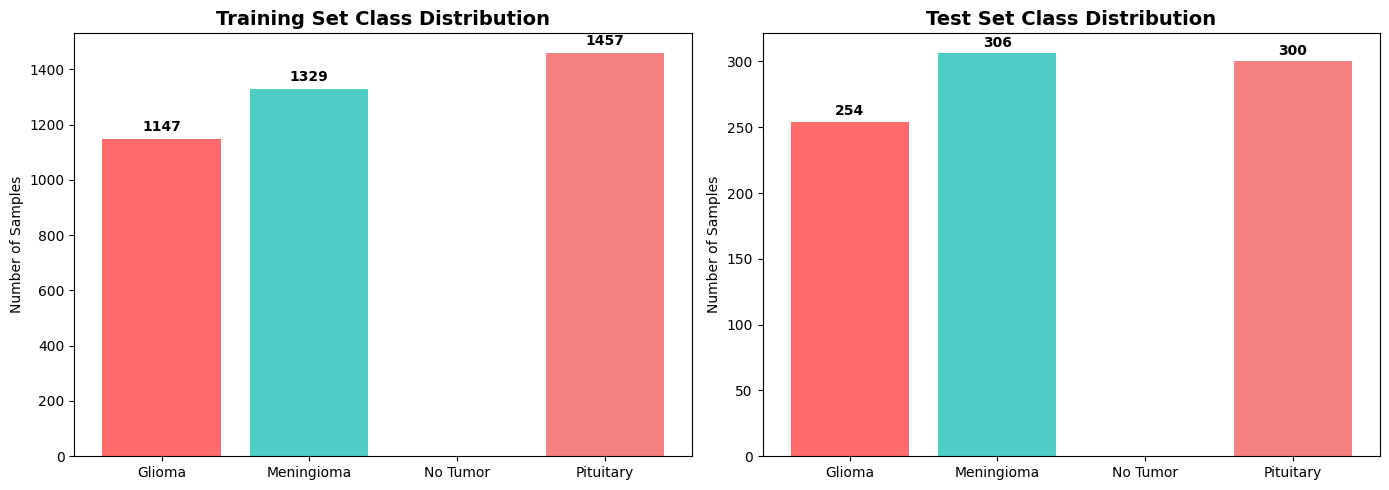

✓ Dataset loaded from segmentation_task


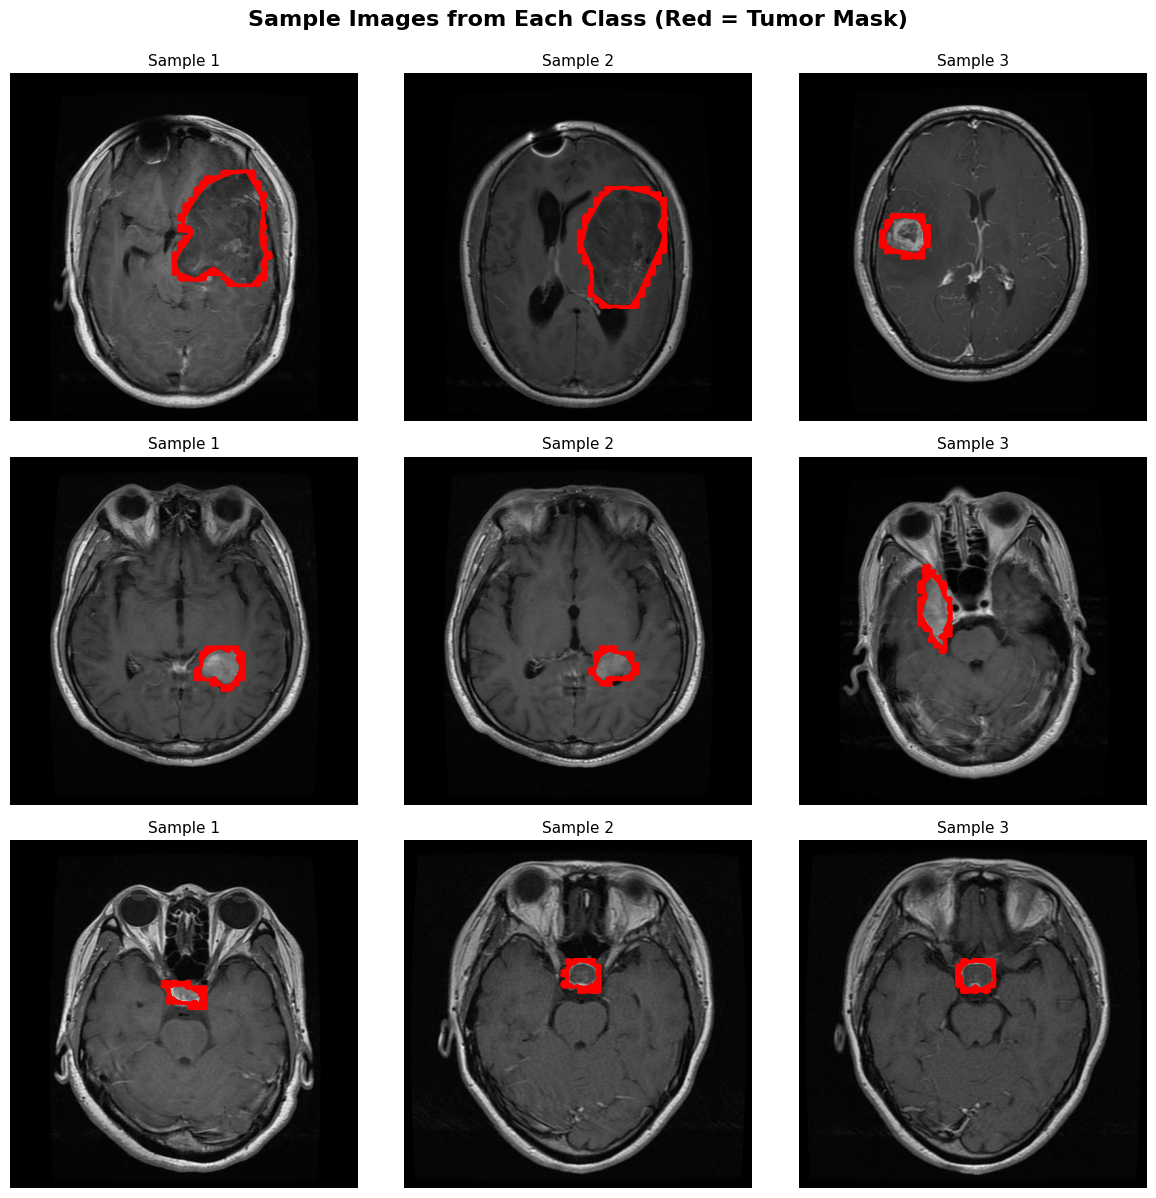

In [39]:
# Class mapping (using codes from filenames)
LABEL_MAP = {'gl': 0, 'me': 1, 'nt': 2, 'pi': 3}
CLASS_NAMES = {0: 'Glioma', 1: 'Meningioma', 2: 'No Tumor', 3: 'Pituitary'}

# Get dataset statistics from both structures
from pathlib import Path

# Segmentation task paths
seg_train_img = Path(config.SEG_TRAIN_IMG)
seg_train_mask = Path(config.SEG_TRAIN_MASK)
seg_test_img = Path(config.SEG_TEST_IMG)
seg_test_mask = Path(config.SEG_TEST_MASK)

# Count images in segmentation task
seg_train_images = sorted(seg_train_img.glob('*.jpg'))
seg_test_images = sorted(seg_test_img.glob('*.jpg'))

print("Dataset Statistics:")
print(f"  Segmentation train images: {len(seg_train_images)}")
print(f"  Segmentation test images: {len(seg_test_images)}")

# Helper function to extract label from filename
def get_label_from_filename(filepath: Path) -> int:
    tokens = filepath.stem.split("_")
    tumor_code = tokens[3]  # gl, me, pi, nt (per README)
    if tumor_code not in LABEL_MAP:
        raise ValueError(f"Unknown tumor code '{tumor_code}' in {filepath.name}")
    return LABEL_MAP[tumor_code]

# Analyze class distribution on train/test from segmentation task
train_labels = [get_label_from_filename(p) for p in seg_train_images]
test_labels = [get_label_from_filename(p) for p in seg_test_images]

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

print("\nTraining Set Distribution (Segmentation Task):")
for label in range(config.NUM_CLASSES_CLASSIFY):
    count = train_counts.get(label, 0)
    if len(train_labels) > 0:
        print(f"  {CLASS_NAMES[label]}: {count} ({count/len(train_labels)*100:.1f}%)")

print("\nTest Set Distribution (Segmentation Task):")
for label in range(config.NUM_CLASSES_CLASSIFY):
    count = test_counts.get(label, 0)
    if len(test_labels) > 0:
        print(f"  {CLASS_NAMES[label]}: {count} ({count/len(test_labels)*100:.1f}%)")


# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
train_data = [train_counts.get(i, 0) for i in range(config.NUM_CLASSES_CLASSIFY)]
labels = [CLASS_NAMES[i] for i in range(config.NUM_CLASSES_CLASSIFY)]
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181']

axes[0].bar(labels, train_data, color=colors)
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, count in enumerate(train_data):
    if count > 0:
        axes[0].text(i, count + 30, str(count), ha='center', fontweight='bold')

# Test set
test_data = [test_counts.get(i, 0) for i in range(config.NUM_CLASSES_CLASSIFY)]
axes[1].bar(labels, test_data, color=colors)
axes[1].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
for i, count in enumerate(test_data):
    if count > 0:
        axes[1].text(i, count + 5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Dataset loaded from segmentation_task")

# Show sample images from each class (only classes with samples)
def show_samples(num_per_class=3):
    samples_by_class = {i: [] for i in range(config.NUM_CLASSES_CLASSIFY)}

    # Collect samples for all classes
    for img_path in seg_train_images:
        label = get_label_from_filename(img_path)
        if label >= 0 and len(samples_by_class[label]) < num_per_class:
            samples_by_class[label].append(img_path)

        # Check if we have enough samples for classes that exist
        if all(len(samples) >= num_per_class or train_counts.get(idx, 0) == 0
               for idx, samples in samples_by_class.items()):
            break

    # Count classes with samples
    classes_with_samples = [i for i in range(config.NUM_CLASSES_CLASSIFY)
                           if len(samples_by_class[i]) > 0]

    if len(classes_with_samples) == 0:
        print("No samples found!")
        return

    # Plot only classes with samples
    fig, axes = plt.subplots(len(classes_with_samples), num_per_class,
                            figsize=(num_per_class*4, len(classes_with_samples)*4))

    if len(classes_with_samples) == 1:
        axes = axes.reshape(1, -1)

    for row_idx, class_idx in enumerate(classes_with_samples):
        for sample_idx in range(min(num_per_class, len(samples_by_class[class_idx]))):
            img_path = samples_by_class[class_idx][sample_idx]
            mask_path = seg_train_mask / (img_path.stem + ".png")

            img = np.array(Image.open(img_path).convert("L"))

            if mask_path.exists():
                mask = np.array(Image.open(mask_path).convert("L"))
            else:
                mask = np.zeros_like(img)

            ax = axes[row_idx, sample_idx] if len(classes_with_samples) > 1 else axes[sample_idx]
            ax.imshow(img, cmap='gray')
            if mask.max() > 0:
                ax.contour(mask, colors='red', linewidths=2)

            if sample_idx == 0:
                ax.set_ylabel(CLASS_NAMES[class_idx], fontsize=14, fontweight='bold')
            ax.set_title(f"Sample {sample_idx + 1}", fontsize=11)
            ax.axis('off')

    plt.suptitle('Sample Images from Each Class (Red = Tumor Mask)',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

show_samples(num_per_class=3)

### 1.3 EDA — Classification


Detected class folders in C:\Users\T2520744\.cache\kagglehub\datasets\briscdataset\brisc2025\versions\6\brisc2025\classification_task\train: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
  glioma          -> label 0 (Glioma):  1147 images
  meningioma      -> label 1 (Meningioma):  1329 images
  no_tumor        -> label 2 (No Tumor):  1067 images
  pituitary       -> label 3 (Pituitary):  1457 images

Detected class folders in C:\Users\T2520744\.cache\kagglehub\datasets\briscdataset\brisc2025\versions\6\brisc2025\classification_task\test: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
  glioma          -> label 0 (Glioma):   254 images
  meningioma      -> label 1 (Meningioma):   306 images
  no_tumor        -> label 2 (No Tumor):   140 images
  pituitary       -> label 3 (Pituitary):   300 images

Classification Dataset Statistics:
  Classification train images: 5000
  Classification test images:  1000

Training Set Distribution (Classification Task):
  Glioma: 1147 (22.9%)
  

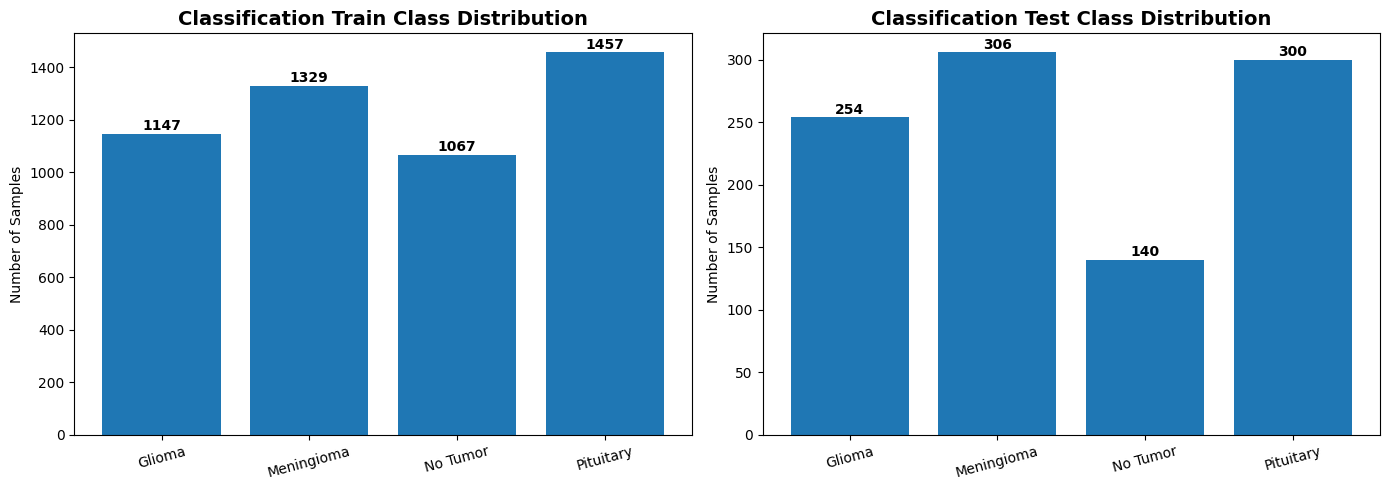

✓ Dataset loaded from classification_task


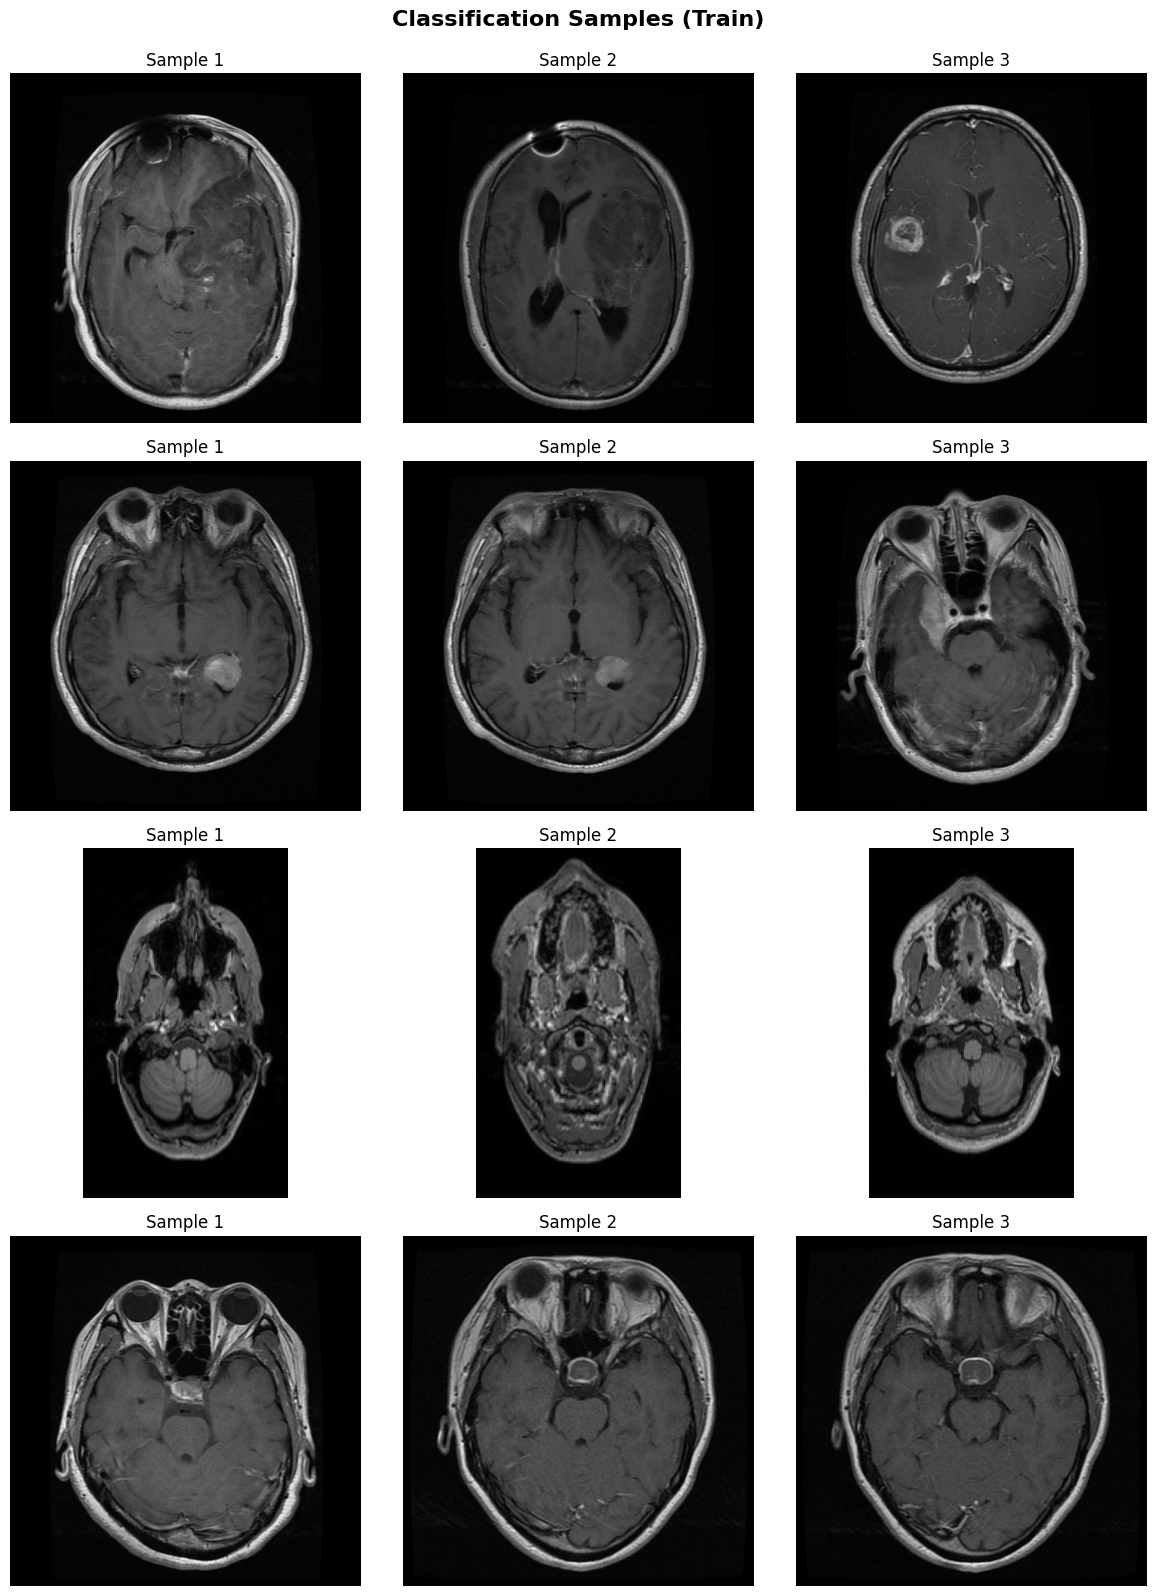

In [40]:
# =========================
# EDA: Classification Task Dataset (4 classes)
# =========================

from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Expected mapping (must match your project config)
CLS_FOLDER_TO_LABEL = {
    "glioma": 0,
    "meningioma": 1,
    "no_tumor": 2,
    "pituitary": 3
}

CLS_CLASS_NAMES = {
    0: "Glioma",
    1: "Meningioma",
    2: "No Tumor",
    3: "Pituitary"
}

def list_images_in_folder(folder: Path):
    return sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.png")) + list(folder.glob("*.jpeg")))

def match_folder_to_label(folder_name: str):
    fname = folder_name.lower().replace(" ", "").replace("-", "_")
    for key, lab in CLS_FOLDER_TO_LABEL.items():
        if key in fname:
            return lab
    return None

def build_classification_manifest(root_dir: Path):
    """
    Builds a list of (img_path, label) from classification_task/{train|test}/*
    """
    root_dir = Path(root_dir)
    if not root_dir.exists():
        raise ValueError(f"Classification root does not exist: {root_dir}")

    img_paths = []
    labels = []

    class_dirs = sorted([d for d in root_dir.iterdir() if d.is_dir()])
    print(f"\nDetected class folders in {root_dir}: {[d.name for d in class_dirs]}")

    for d in class_dirs:
        label = match_folder_to_label(d.name)
        if label is None:
            print(f"  ⚠️ Skipping unknown folder: {d.name}")
            continue

        files = list_images_in_folder(d)
        img_paths.extend(files)
        labels.extend([label] * len(files))

        print(f"  {d.name:15s} -> label {label} ({CLS_CLASS_NAMES[label]}): {len(files):5d} images")

    if len(img_paths) == 0:
        raise ValueError(f"No images found under: {root_dir}")

    return img_paths, labels

# ---- Paths (use your config if available; otherwise infer from DATA_ROOT) ----
data_root = Path(config.DATA_ROOT)

cls_train_root = data_root / "classification_task" / "train"
cls_test_root  = data_root / "classification_task" / "test"

# Build manifests
cls_train_images, cls_train_labels = build_classification_manifest(cls_train_root)
cls_test_images, cls_test_labels   = build_classification_manifest(cls_test_root)

# Counts
train_counts = Counter(cls_train_labels)
test_counts  = Counter(cls_test_labels)

print("\nClassification Dataset Statistics:")
print(f"  Classification train images: {len(cls_train_images)}")
print(f"  Classification test images:  {len(cls_test_images)}")

print("\nTraining Set Distribution (Classification Task):")
for i in range(4):
    c = train_counts.get(i, 0)
    print(f"  {CLS_CLASS_NAMES[i]}: {c} ({c/len(cls_train_labels)*100:.1f}%)" if len(cls_train_labels) else f"  {CLS_CLASS_NAMES[i]}: {c}")

print("\nTest Set Distribution (Classification Task):")
for i in range(4):
    c = test_counts.get(i, 0)
    print(f"  {CLS_CLASS_NAMES[i]}: {c} ({c/len(cls_test_labels)*100:.1f}%)" if len(cls_test_labels) else f"  {CLS_CLASS_NAMES[i]}: {c}")

# ---- Plot distributions ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [CLS_CLASS_NAMES[i] for i in range(4)]
train_data = [train_counts.get(i, 0) for i in range(4)]
test_data  = [test_counts.get(i, 0) for i in range(4)]

axes[0].bar(labels, train_data)
axes[0].set_title("Classification Train Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=15)

for i, count in enumerate(train_data):
    if count > 0:
        axes[0].text(i, count + max(train_data)*0.01, str(count), ha="center", fontweight="bold")

axes[1].bar(labels, test_data)
axes[1].set_title("Classification Test Class Distribution", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Number of Samples")
axes[1].tick_params(axis="x", rotation=15)

for i, count in enumerate(test_data):
    if count > 0:
        axes[1].text(i, count + max(test_data)*0.01 if max(test_data)>0 else 1, str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("✓ Dataset loaded from classification_task")

# ---- Show sample images per class ----
def show_classification_samples(num_per_class=3, use_train=True):
    images = cls_train_images if use_train else cls_test_images
    labels_list = cls_train_labels if use_train else cls_test_labels

    # Build per-class samples
    samples = {i: [] for i in range(4)}
    for p, lab in zip(images, labels_list):
        if len(samples[lab]) < num_per_class:
            samples[lab].append(p)
        if all(len(samples[i]) >= num_per_class or (train_counts.get(i,0)==0 and use_train) or (test_counts.get(i,0)==0 and not use_train)
               for i in range(4)):
            break

    classes_with_samples = [i for i in range(4) if len(samples[i]) > 0]
    if len(classes_with_samples) == 0:
        print("No samples found to display.")
        return

    fig, axes = plt.subplots(len(classes_with_samples), num_per_class, figsize=(num_per_class*4, len(classes_with_samples)*4))
    if len(classes_with_samples) == 1:
        axes = axes.reshape(1, -1)

    for r, cls_id in enumerate(classes_with_samples):
        for c in range(min(num_per_class, len(samples[cls_id]))):
            img = np.array(Image.open(samples[cls_id][c]).convert("L"))
            ax = axes[r, c]
            ax.imshow(img, cmap="gray")
            if c == 0:
                ax.set_ylabel(CLS_CLASS_NAMES[cls_id], fontsize=14, fontweight="bold")
            ax.set_title(f"Sample {c+1}")
            ax.axis("off")

    split_name = "Train" if use_train else "Test"
    plt.suptitle(f"Classification Samples ({split_name})", fontsize=16, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()

# Show samples from train by default
show_classification_samples(num_per_class=3, use_train=True)

## 2) TRANSFORMS

### 2.1 Segmentation Transforms

In [41]:
# =============================================================================
# SEGMENTATION TRANSFORMS
# =============================================================================

def get_seg_train_transforms(image_size, mean, std):
    """Training transforms for segmentation (with augmentation)"""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Normalize(mean=[mean], std=[std]),
        ToTensorV2()
    ])

def get_seg_val_transforms(image_size, mean, std):
    """Validation transforms for segmentation (no augmentation)"""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=[mean], std=[std]),
        ToTensorV2()
    ])

# Create transforms
seg_train_transform = get_seg_train_transforms(
    config.IMAGE_SIZE,
    dataset_mean,
    dataset_std
)

seg_val_transform = get_seg_val_transforms(
    config.IMAGE_SIZE,
    dataset_mean,
    dataset_std
)

print("✓ Segmentation transforms created")
print(f"  Train: Resize + Augmentation + Normalize + ToTensor")
print(f"  Val/Test: Resize + Normalize + ToTensor")

✓ Segmentation transforms created
  Train: Resize + Augmentation + Normalize + ToTensor
  Val/Test: Resize + Normalize + ToTensor


### 2.2 Classification Transforms

In [42]:
# =============================================================================
# CLASSIFICATION TRANSFORMS
# =============================================================================

def get_cls_train_transforms(image_size, mean, std):
    """Training transforms for classification (with augmentation)"""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Normalize(mean=[mean], std=[std]),
        ToTensorV2()
    ])

def get_cls_val_transforms(image_size, mean, std):
    """Validation transforms for classification (no augmentation)"""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=[mean], std=[std]),
        ToTensorV2()
    ])

# Create transforms
cls_train_transform = get_cls_train_transforms(
    config.IMAGE_SIZE,
    dataset_mean,
    dataset_std
)

cls_val_transform = get_cls_val_transforms(
    config.IMAGE_SIZE,
    dataset_mean,
    dataset_std
)

print("✓ Classification transforms created")
print(f"  Train: Resize + Augmentation + Normalize + ToTensor")
print(f"  Val/Test: Resize + Normalize + ToTensor")
print(f"  NOTE: No mask handling (classification only)")

✓ Classification transforms created
  Train: Resize + Augmentation + Normalize + ToTensor
  Val/Test: Resize + Normalize + ToTensor
  NOTE: No mask handling (classification only)


## 3) DATASETS & DATALOADERS

### 3.1 Segmentation Dataset Class (ONLY ONE)

In [43]:
# =============================================================================
# SEGMENTATION DATASET
# =============================================================================

class BrainSegmentationDataset(Dataset):
    """Segmentation dataset - returns {image, mask, path}"""

    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform

        # Get all image paths
        self.image_paths = sorted(list(self.image_dir.glob("*.jpg")))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image (grayscale)
        img_path = self.image_paths[idx]
        img = np.array(Image.open(img_path).convert('L'))

        # Load mask (binary)
        mask_path = self.mask_dir / (img_path.stem + '.png')
        mask = (np.array(Image.open(mask_path).convert('L')) > 0).astype(np.uint8)

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

            # Ensure mask is 3D: (1, H, W)
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
            mask = mask.float()
        else:
            img = torch.from_numpy(img).unsqueeze(0).float() / 255.0
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        return {
            'image': img,
            'mask': mask,
            'path': str(img_path)
        }

print("✓ BrainSegmentationDataset class defined")
print("  Returns: {image, mask, path}")
print("  Grayscale: IN_CHANNELS=1")

✓ BrainSegmentationDataset class defined
  Returns: {image, mask, path}
  Grayscale: IN_CHANNELS=1


### 3.2 Segmentation Split + Loaders (Create ONCE)

In [44]:
# =============================================================================
# SEGMENTATION DATA LOADING
# =============================================================================

print("="*80)
print("CREATING SEGMENTATION DATASETS & LOADERS")
print("="*80)

# Create full training dataset
seg_train_full = BrainSegmentationDataset(
    image_dir=config.SEG_TRAIN_IMG,
    mask_dir=config.SEG_TRAIN_MASK,
    transform=None  # Will split first, then apply transforms
)

# Split train -> train/val
train_indices = list(range(len(seg_train_full)))
train_idx, val_idx = train_test_split(
    train_indices,
    test_size=config.VAL_SPLIT,
    random_state=config.SEED
)

if QUICK_RUN:
    train_idx, val_idx = train_idx[:QUICK_RUN_SAMPLES], val_idx[:QUICK_RUN_SAMPLES]

print(f"\nSegmentation split:")
print(f"  Train: {len(train_idx)} images")
print(f"  Val:   {len(val_idx)} images")

# Create datasets with transforms
from torch.utils.data import Subset

class SegSubset(Dataset):
    """Subset with transforms applied"""
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img_path = self.dataset.image_paths[real_idx]

        # Load image and mask
        img = np.array(Image.open(img_path).convert('L'))
        mask_path = self.dataset.mask_dir / (img_path.stem + '.png')
        mask = (np.array(Image.open(mask_path).convert('L')) > 0).astype(np.uint8)

        # Apply transformPIN_MEMORY
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
            mask = mask.float()
        else:
            img = torch.from_numpy(img).unsqueeze(0).float() / 255.0
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        return {'image': img, 'mask': mask, 'path': str(img_path)}

# Create train/val datasets
seg_train_dataset = SegSubset(seg_train_full, train_idx, seg_train_transform)
seg_val_dataset = SegSubset(seg_train_full, val_idx, seg_val_transform)

# Create test dataset
seg_test_dataset = BrainSegmentationDataset(
    image_dir=config.SEG_TEST_IMG,
    mask_dir=config.SEG_TEST_MASK,
    transform=seg_val_transform
)

if QUICK_RUN:
    step = len(seg_test_dataset) // QUICK_RUN_SAMPLES
    seg_test_dataset.image_paths = seg_test_dataset.image_paths[::step][:QUICK_RUN_SAMPLES]

print(f"  Test:  {len(seg_test_dataset)} images")

# Create DataLoaders
seg_train_loader = DataLoader(
    seg_train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY
)

seg_val_loader = DataLoader(
    seg_val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY
)

seg_test_loader = DataLoader(
    seg_test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY
)

print(f"\n✓ Segmentation loaders created:")
print(f"  seg_train_loader: {len(seg_train_loader)} batches")
print(f"  seg_val_loader:   {len(seg_val_loader)} batches")
print(f"  seg_test_loader:  {len(seg_test_loader)} batches")
print("="*80)

CREATING SEGMENTATION DATASETS & LOADERS

Segmentation split:
  Train: 3146 images
  Val:   787 images
  Test:  860 images

✓ Segmentation loaders created:
  seg_train_loader: 394 batches
  seg_val_loader:   99 batches
  seg_test_loader:  108 batches


### 3.3 Classification Dataset Class (ONLY ONE)

In [45]:
# =============================================================================
# CLASSIFICATION DATASET
# =============================================================================

class BrainClassificationDataset(Dataset):
    """Classification dataset - returns {image, label, path}"""

    # Fixed label mapping
    LABEL_MAP = {
        'glioma': 0,
        'meningioma': 1,
        'no_tumor': 2,
        'pituitary': 3
    }

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform

        # Collect all images
        self.samples = []
        self.labels = []

        for class_name, label in self.LABEL_MAP.items():
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                continue

            for img_path in class_dir.glob("*.jpg"):
                self.samples.append(img_path)
                self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        label = self.labels[idx]

        # Load image (grayscale)
        img = np.array(Image.open(img_path).convert('L'))

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']
        else:
            img = torch.from_numpy(img).unsqueeze(0).float() / 255.0

        return {
            'image': img,
            'label': torch.tensor(label, dtype=torch.long),
            'path': str(img_path)
        }

print("✓ BrainClassificationDataset class defined")
print("  Returns: {image, label, path}")
print("  Label mapping:")
print("    glioma     = 0")
print("    meningioma = 1")
print("    no_tumor   = 2")
print("    pituitary  = 3")
print("  Grayscale: IN_CHANNELS=1")

✓ BrainClassificationDataset class defined
  Returns: {image, label, path}
  Label mapping:
    glioma     = 0
    meningioma = 1
    no_tumor   = 2
    pituitary  = 3
  Grayscale: IN_CHANNELS=1


### 3.4 Classification Split + Loaders (Create ONCE)

In [46]:
# =============================================================================
# CLASSIFICATION DATA LOADING
# =============================================================================

print("="*80)
print("CREATING CLASSIFICATION DATASETS & LOADERS")
print("="*80)

# Create full training dataset
cls_train_full = BrainClassificationDataset(
    root_dir=config.CLASS_TRAIN,
    transform=None
)

# Stratified split
all_indices = list(range(len(cls_train_full)))
all_labels = cls_train_full.labels

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=config.VAL_SPLIT,
    stratify=all_labels,
    random_state=config.SEED
)

if QUICK_RUN:
    train_idx, val_idx = train_idx[:QUICK_RUN_SAMPLES], val_idx[:QUICK_RUN_SAMPLES]

print(f"\nClassification split:")
print(f"  Train: {len(train_idx)} images")
print(f"  Val:   {len(val_idx)} images")

# Create subsets with transforms
class ClsSubset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img_path = self.dataset.samples[real_idx]
        label = self.dataset.labels[real_idx]

        img = np.array(Image.open(img_path).convert('L'))

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']
        else:
            img = torch.from_numpy(img).unsqueeze(0).float() / 255.0

        return {
            'image': img,
            'label': torch.tensor(label, dtype=torch.long),
            'path': str(img_path)
        }

cls_train_dataset = ClsSubset(cls_train_full, train_idx, cls_train_transform)
cls_val_dataset = ClsSubset(cls_train_full, val_idx, cls_val_transform)

# Test dataset
cls_test_dataset = BrainClassificationDataset(
    root_dir=config.CLASS_TEST,
    transform=cls_val_transform
)

if QUICK_RUN:
    # Strided so every class (samples are grouped by class folder) is kept
    step = len(cls_test_dataset) // QUICK_RUN_SAMPLES
    cls_test_dataset.samples = cls_test_dataset.samples[::step][:QUICK_RUN_SAMPLES]
    cls_test_dataset.labels = cls_test_dataset.labels[::step][:QUICK_RUN_SAMPLES]

print(f"  Test:  {len(cls_test_dataset)} images")

# Create loaders
cls_train_loader = DataLoader(
    cls_train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY
)

cls_val_loader = DataLoader(
    cls_val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY
)

cls_test_loader = DataLoader(
    cls_test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY
)

print(f"\n✓ Classification loaders created:")
print(f"  cls_train_loader: {len(cls_train_loader)} batches")
print(f"  cls_val_loader:   {len(cls_val_loader)} batches")
print(f"  cls_test_loader:  {len(cls_test_loader)} batches")
print("="*80)

CREATING CLASSIFICATION DATASETS & LOADERS

Classification split:
  Train: 4000 images
  Val:   1000 images
  Test:  1000 images

✓ Classification loaders created:
  cls_train_loader: 500 batches
  cls_val_loader:   125 batches
  cls_test_loader:  125 batches


#### Sanity Check - Classification Loaders

In [47]:
# =============================================================================
# SANITY CHECK - CLASSIFICATION LOADERS
# =============================================================================

print("="*80)
print("SANITY CHECK: Classification Loaders")
print("="*80)

# Check batch structure
batch = next(iter(cls_train_loader))

print(f"\n✓ Batch keys: {batch.keys()}")
print(f"  Image shape: {batch['image'].shape}")
print(f"  Label shape: {batch['label'].shape}")

# Should NOT have 'mask'
assert 'mask' not in batch, "ERROR: Classification batch should NOT have 'mask'"
print(f"  ✓ No 'mask' in classification batch")

# Check all 4 labels exist
all_labels = []
for b in cls_train_loader:
    all_labels.extend(b['label'].tolist())

label_counts = Counter(all_labels)

print(f"\n✓ Label distribution:")
for label in range(config.NUM_CLASSES_CLASSIFY):
    count = label_counts.get(label, 0)
    print(f"  {label} ({config.CLASS_NAMES[label]:15s}): {count:5d} samples")

# Check all labels present
for label in range(config.NUM_CLASSES_CLASSIFY):
    assert label_counts.get(label, 0) > 0, f"ERROR: Label {label} has 0 samples!"

print(f"\n✅ PASS: All 4 classes present in classification data")
print("="*80)

SANITY CHECK: Classification Loaders

✓ Batch keys: dict_keys(['image', 'label', 'path'])
  Image shape: torch.Size([8, 1, 256, 256])
  Label shape: torch.Size([8])
  ✓ No 'mask' in classification batch

✓ Label distribution:
  0 (Glioma         ):   918 samples
  1 (Meningioma     ):  1063 samples
  2 (No Tumor       ):   854 samples
  3 (Pituitary      ):  1165 samples

✅ PASS: All 4 classes present in classification data


## 4) MODELS

### 4.1 U-Net Backbone (Encoder + Decoder)

In [48]:
# =============================================================================
# U-NET ARCHITECTURE
# =============================================================================

class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2"""
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    """Downsampling: MaxPool → DoubleConv"""
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    """Upsampling: TransposedConv → Concat → DoubleConv"""
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    @staticmethod
    def _pad_to_match(x1, x2):
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        return F.pad(
            x1,
            [diff_x // 2, diff_x - diff_x // 2,
             diff_y // 2, diff_y - diff_y // 2]
        )

    def forward(self, x_decoder, x_encoder):
        x_decoder = self.up(x_decoder)
        x_decoder = self._pad_to_match(x_decoder, x_encoder)
        x = torch.cat([x_encoder, x_decoder], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """U-Net for segmentation only"""
    def __init__(
        self,
        in_channels: int = 1,
        num_classes: int = 1,
        base_channels: int = 64
    ):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = Down(base_channels, base_channels * 2)
        self.enc3 = Down(base_channels * 2, base_channels * 4)
        self.enc4 = Down(base_channels * 4, base_channels * 8)
        self.enc5 = Down(base_channels * 8, base_channels * 16)

        # Decoder
        self.dec1 = Up(base_channels * 16, base_channels * 8)
        self.dec2 = Up(base_channels * 8, base_channels * 4)
        self.dec3 = Up(base_channels * 4, base_channels * 2)
        self.dec4 = Up(base_channels * 2, base_channels)

        # Segmentation output head
        self.out = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder path
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)
        x5 = self.enc5(x4)

        # Decoder path
        x = self.dec1(x5, x4)
        x = self.dec2(x, x3)
        x = self.dec3(x, x2)
        x = self.dec4(x, x1)

        # Output
        return self.out(x)

    def get_encoder_features(self, x):
        """Extract deep encoder features for classification"""
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)
        x5 = self.enc5(x4)
        return x5


print("✓ U-Net architecture defined")
print("  Clean implementation with DoubleConv/Down/Up blocks")
print("  Encoder: 5 levels (enc1-enc5)")
print("  Decoder: 4 upsampling stages (dec1-dec4)")
print("  Output: Conv → logits (segmentation only)")

✓ U-Net architecture defined
  Clean implementation with DoubleConv/Down/Up blocks
  Encoder: 5 levels (enc1-enc5)
  Decoder: 4 upsampling stages (dec1-dec4)
  Output: Conv → logits (segmentation only)


### 4.2 Test Model

In [49]:
# =============================================================================
# TEST MODEL
# =============================================================================

# Create model
test_model = UNet(
    in_channels=config.IN_CHANNELS,
    num_classes=config.NUM_CLASSES_SEG,
    base_channels=config.BASE_CHANNELS
).eval().to(config.DEVICE)

# Test forward pass
test_input = torch.randn(2, config.IN_CHANNELS, config.IMAGE_SIZE, config.IMAGE_SIZE).to(config.DEVICE)
seg_out = test_model(test_input)  # Only segmentation output now

print("="*80)
print("MODEL TEST")
print("="*80)
print(f"Input shape:  {test_input.shape}")
print(f"Seg output:   {seg_out.shape} (expected: [B, 1, H, W])")

# Count parameters
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("="*80)

# Clean up
del test_model, test_input, seg_out
torch.cuda.empty_cache() if torch.cuda.is_available() else None

MODEL TEST
Input shape:  torch.Size([2, 1, 256, 256])
Seg output:   torch.Size([2, 2, 256, 256]) (expected: [B, 1, H, W])

Total parameters: 31,036,546
Trainable parameters: 31,036,546


### 4.3 Classifier Head (Uses UNet Encoder Features)

In [50]:
# =============================================================================
# CLASSIFIER HEAD (PRETRAINED MOBILENET ON UNET FEATURES)
# =============================================================================

class classifierhead(nn.Module):
    """
    Pretrained MobileNetV2-based classifier for UNet encoder features.
    
    Architecture:
    - Adapter: Maps 1024 UNet features → 3 channels (RGB for MobileNet)
    - Pretrained MobileNetV2 backbone (ImageNet weights)
    - Custom classification head with BatchNorm + Dropout
    
    Benefits:
    - Leverages ImageNet pretrained weights (better initialization)
    - Two-stage transfer learning:
      1. ImageNet → MobileNet features
      2. UNet segmentation → Classification
    - Proven architecture with state-of-the-art performance
    """
    def __init__(self, encoder_channels=1024, num_classes=4, pretrained=True):
        super(classifierhead, self).__init__()
        
        # Adapter: Convert UNet encoder features (1024 ch) to RGB-like (3 ch)
        # This allows us to use pretrained MobileNet weights
        self.adapter = nn.Sequential(
            nn.Conv2d(encoder_channels, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 3, kernel_size=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(inplace=True)
        )
        
        # Load pretrained MobileNetV2
        mobilenet = models.mobilenet_v2(pretrained=pretrained)
        
        # Extract feature layers (remove original classifier)
        self.features = mobilenet.features
        
        # MobileNetV2 outputs 1280 feature channels
        # Custom classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            
            nn.Dropout(0.5),
            nn.Linear(1280, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, encoder_features):
        """
        Args:
            encoder_features: UNet encoder output (B, 1024, H/16, W/16)
        Returns:
            class_logits: (B, num_classes)
        """
        # Adapt encoder features to 3 channels
        x = self.adapter(encoder_features)
        
        # MobileNetV2 feature extraction
        x = self.features(x)
        
        # Classification
        x = self.classifier(x)
        return x


print("✓ classifierhead defined")
print("  Input: UNet encoder features (1024 channels)")
print("  Adapter: 1024 → 512 → 3 channels")
print("  Backbone: MobileNetV2 (pretrained on ImageNet)")
print("  Output: 4 tumor classes")
print("  Transfer learning: Segmentation + ImageNet knowledge combined")

✓ classifierhead defined
  Input: UNet encoder features (1024 channels)
  Adapter: 1024 → 512 → 3 channels
  Backbone: MobileNetV2 (pretrained on ImageNet)
  Output: 4 tumor classes
  Transfer learning: Segmentation + ImageNet knowledge combined


In [51]:
# =============================================================================
# TEST UNET + CLASSIFIER PIPELINE
# =============================================================================

# Create UNet (for encoder features)
test_unet = UNet(
    in_channels=config.IN_CHANNELS,
    num_classes=config.NUM_CLASSES_SEG,
    base_channels=config.BASE_CHANNELS
).eval().to(config.DEVICE)

# Create classifier
test_classifier = classifierhead(
    encoder_channels=config.BASE_CHANNELS * 16,  # 64 * 16 = 1024
    num_classes=config.NUM_CLASSES_CLASSIFY,
    pretrained=True
).eval().to(config.DEVICE)

# Test forward pass
test_input = torch.randn(2, config.IN_CHANNELS, config.IMAGE_SIZE, config.IMAGE_SIZE).to(config.DEVICE)

# Extract encoder features
encoder_features = test_unet.get_encoder_features(test_input)

# Classify using encoder features
cls_out = test_classifier(encoder_features)

print("="*80)
print("UNET + CLASSIFIER PIPELINE TEST")
print("="*80)
print(f"Input shape:           {test_input.shape}")
print(f"Encoder features:      {encoder_features.shape}")
print(f"Classification output: {cls_out.shape} (expected: [B, 4])")

# Count parameters

unet_params = sum(p.numel() for p in test_unet.parameters())
# Free GPU memory if available (no-op on CPU)
torch.cuda.empty_cache() if torch.cuda.is_available() else None

classifier_params = sum(p.numel() for p in test_classifier.parameters())

# Clean up temporary objects to reduce memory pressure
del test_unet, test_classifier, test_input, encoder_features, cls_out

print(f"\nParameters:")
print(f"  UNet encoder+decoder: {unet_params:,}")
print("="*80)
print(f"  Classifier head:      {classifier_params:,}")
print(f"\n✓ Pipeline: Image → UNet Encoder → Features → Classifier → Class")
print(f"  Total:                {unet_params + classifier_params:,}")

UNET + CLASSIFIER PIPELINE TEST
Input shape:           torch.Size([2, 1, 256, 256])
Encoder features:      torch.Size([2, 1024, 16, 16])
Classification output: torch.Size([2, 4]) (expected: [B, 4])

Parameters:
  UNet encoder+decoder: 31,036,546
  Classifier head:      3,540,490

✓ Pipeline: Image → UNet Encoder → Features → Classifier → Class
  Total:                34,577,036


## 5) TRAINING — SEGMENTATION STAGE

### 5.1 Loss (Seg Only)

In [52]:
# =============================================================================
# SEGMENTATION LOSS
# =============================================================================

class DiceBCELoss(nn.Module):
    """Combined Dice + BCE loss for segmentation"""

    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss()

    def dice_loss(self, pred, target, smooth=1e-6):
        # If pred has 2 channels, take only the first channel
        if pred.shape[1] == 2:
            pred = pred[:, 1:2, :, :]  # Grab Channel 1 (Tumor), ignore Channel 0 (Background)
        
        pred = torch.sigmoid(pred)
        target = target.float()
        
        # Use dimension-wise sum instead of flattening
        inter = (pred * target).sum(dim=(0, 2, 3))
        union = (pred + target).sum(dim=(0, 2, 3))
        
        dice = (2 * inter + smooth) / (union + smooth)
        return 1.0 - dice.mean()

    def forward(self, pred, target):
        # If pred has 2 channels, take only the first channel
        if pred.shape[1] == 2:
            pred = pred[:, 1:2, :, :]  # Grab Channel 1 (Tumor), ignore Channel 0 (Background)
        
        dice = self.dice_loss(pred, target)
        bce = self.bce(pred, target)

        return self.dice_weight * dice + self.bce_weight * bce

print("✓ DiceBCELoss defined")
print("  Combines Dice loss + BCE loss")
print("  For segmentation only")
print("  Note: If model outputs 2 channels, only first channel is used for loss")

✓ DiceBCELoss defined
  Combines Dice loss + BCE loss
  For segmentation only
  Note: If model outputs 2 channels, only first channel is used for loss


### 5.2 Epoch Functions (Seg Only)

In [53]:
# =============================================================================
# SEGMENTATION TRAINING FUNCTIONS
# =============================================================================

def compute_seg_metrics(pred, target, threshold=0.5):
    """Compute Dice, mIoU, Pixel Accuracy"""
    # If pred has 2 channels, take only the first channel
    if pred.shape[1] == 2:
        pred = pred[:, 1:2, :]
    
    pred = torch.sigmoid(pred)
    pred_bin = (pred > threshold).float()

    # Flatten
    pred_bin = pred_bin.view(-1)
    target = target.view(-1)

    # Intersection and union
    intersection = (pred_bin * target).sum()
    union = pred_bin.sum() + target.sum() - intersection

    # Metrics
    dice = (2.0 * intersection) / (pred_bin.sum() + target.sum() + 1e-6)
    iou = intersection / (union + 1e-6)
    pixel_acc = (pred_bin == target).float().mean()

    return {
        'dice': dice.item(),
        'miou': iou.item(),
        'pixel_acc': pixel_acc.item()
    }

def train_epoch_seg(model, loader, optimizer, criterion, device):
    """Train one epoch - segmentation only"""
    model.train()
    total_loss = 0
    all_metrics = {'dice': [], 'miou': [], 'pixel_acc': []}

    pbar = tqdm(loader, desc="Training", leave=False)

    for batch in pbar:
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        # Forward (segmentation only)
        seg_logits = model(images)
        loss = criterion(seg_logits, masks)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        metrics = compute_seg_metrics(seg_logits.detach(), masks)
        for k, v in metrics.items():
            all_metrics[k].append(v)

        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'dice': f"{metrics['dice']:.4f}"})

    # Average
    avg_loss = total_loss / len(loader)
    avg_metrics = {k: np.mean(v) for k, v in all_metrics.items()}

    return avg_loss, avg_metrics

@torch.no_grad()
def validate_epoch_seg(model, loader, criterion, device):
    """Validate one epoch - segmentation only"""
    model.eval()
    total_loss = 0
    all_metrics = {'dice': [], 'miou': [], 'pixel_acc': []}

    pbar = tqdm(loader, desc="Validation", leave=False)

    for batch in pbar:
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        # Forward (segmentation only)
        seg_logits = model(images)
        loss = criterion(seg_logits, masks)

        # Metrics
        total_loss += loss.item()
        metrics = compute_seg_metrics(seg_logits, masks)
        for k, v in metrics.items():
            all_metrics[k].append(v)

        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'dice': f"{metrics['dice']:.4f}"})

    # Average
    avg_loss = total_loss / len(loader)
    avg_metrics = {k: np.mean(v) for k, v in all_metrics.items()}

    return avg_loss, avg_metrics

print("✓ Segmentation training functions defined")
print("  train_epoch_seg: trains on seg data, computes seg metrics")
print("  validate_epoch_seg: validates on seg data, computes seg metrics")
print("  Metrics: Dice, mIoU, Pixel Accuracy")
print("  Note: If model outputs 2 channels, only first channel is used for metrics")

✓ Segmentation training functions defined
  train_epoch_seg: trains on seg data, computes seg metrics
  validate_epoch_seg: validates on seg data, computes seg metrics
  Metrics: Dice, mIoU, Pixel Accuracy
  Note: If model outputs 2 channels, only first channel is used for metrics


### 5.3 Train U-Net Segmentation

In [54]:
# =============================================================================
# TRAIN SEGMENTATION STAGE
# =============================================================================

print("="*80)
print("TRAINING SEGMENTATION (STAGE 1)")
print("="*80)

# Create UNet model (segmentation only)
unet_model = UNet(
    in_channels=config.IN_CHANNELS,
    num_classes=config.NUM_CLASSES_SEG,
    base_channels=config.BASE_CHANNELS
).to(config.DEVICE)

print(f"\n✓ Model created:")
print(f"  Input channels: {config.IN_CHANNELS}")
print(f"  Output classes: {config.NUM_CLASSES_SEG}")
print(f"  Base channels: {config.BASE_CHANNELS}")
print(f"  Device: {config.DEVICE}\n")

# Loss and optimizer
seg_criterion = DiceBCELoss(dice_weight=0.5, bce_weight=0.5)
seg_optimizer = torch.optim.AdamW(
    unet_model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)
seg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    seg_optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    verbose=True
)

# Training history
unet_seg_history = {
    'train_loss': [], 'val_loss': [],
    'train_dice': [], 'val_dice': [],
    'train_miou': [], 'val_miou': [],
    'train_pixel_acc': [], 'val_pixel_acc': []
}

best_dice = 0.0

print(f"\nTraining for {config.NUM_EPOCHS} epochs...")
print(f"Device: {config.DEVICE}")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Learning rate: {config.LEARNING_RATE}")
print()

# Training loop
for epoch in range(config.NUM_EPOCHS):
    # Train
    train_loss, train_metrics = train_epoch_seg(
        unet_model, seg_train_loader, seg_optimizer, seg_criterion, config.DEVICE
    )

    # Validate
    val_loss, val_metrics = validate_epoch_seg(
        unet_model, seg_val_loader, seg_criterion, config.DEVICE
    )

    # Update scheduler
    seg_scheduler.step(val_metrics['dice'])

    # Store history
    unet_seg_history['train_loss'].append(train_loss)
    unet_seg_history['val_loss'].append(val_loss)
    unet_seg_history['train_dice'].append(train_metrics['dice'])
    unet_seg_history['val_dice'].append(val_metrics['dice'])
    unet_seg_history['train_miou'].append(train_metrics['miou'])
    unet_seg_history['val_miou'].append(val_metrics['miou'])
    unet_seg_history['train_pixel_acc'].append(train_metrics['pixel_acc'])
    unet_seg_history['val_pixel_acc'].append(val_metrics['pixel_acc'])

    # Print
    print(f"Epoch {epoch+1}/{config.NUM_EPOCHS}")
    print(f"  Loss: {train_loss:.4f} / {val_loss:.4f}")
    print(f"  Dice: {train_metrics['dice']:.4f} / {val_metrics['dice']:.4f}")
    print(f"  mIoU: {train_metrics['miou']:.4f} / {val_metrics['miou']:.4f}")
    print(f"  Pixel Acc: {train_metrics['pixel_acc']:.4f} / {val_metrics['pixel_acc']:.4f}")

    # Save best
    if val_metrics['dice'] > best_dice:
        best_dice = val_metrics['dice']
        torch.save({
            'epoch': epoch,
            'model_state_dict': unet_model.state_dict(),
            'optimizer_state_dict': seg_optimizer.state_dict(),
            'best_dice': best_dice,
            'history': unet_seg_history
        }, 'unet_seg_best.pth')
        print(f"  ✓ Saved checkpoint (Dice: {best_dice:.4f})")
    print()


print(f"\n✅ Segmentation training complete!")
print("="*80)

print(f"   Best Dice: {best_dice:.4f}")
print(f"   Checkpoint: unet_seg_best.pth")

TRAINING SEGMENTATION (STAGE 1)

✓ Model created:
  Input channels: 1
  Output classes: 2
  Base channels: 64
  Device: cuda


Training for 50 epochs...
Device: cuda
Batch size: 8
Learning rate: 5e-05



Epoch 1/50
  Loss: 0.6357 / 0.5645
  Dice: 0.4435 / 0.6618
  mIoU: 0.3061 / 0.5056
  Pixel Acc: 0.9641 / 0.9881
  ✓ Saved checkpoint (Dice: 0.6618)



Epoch 2/50
  Loss: 0.5427 / 0.5106
  Dice: 0.6349 / 0.6619
  mIoU: 0.4763 / 0.5027
  Pixel Acc: 0.9849 / 0.9861
  ✓ Saved checkpoint (Dice: 0.6619)



Epoch 3/50
  Loss: 0.4843 / 0.4547
  Dice: 0.6717 / 0.7145
  mIoU: 0.5165 / 0.5648
  Pixel Acc: 0.9861 / 0.9891
  ✓ Saved checkpoint (Dice: 0.7145)



Epoch 4/50
  Loss: 0.4281 / 0.4118
  Dice: 0.7008 / 0.7152
  mIoU: 0.5485 / 0.5652
  Pixel Acc: 0.9875 / 0.9899
  ✓ Saved checkpoint (Dice: 0.7152)



...

Epoch 46/50
  Loss: 0.0711 / 0.0918
  Dice: 0.8797 / 0.8451
  mIoU: 0.7876 / 0.7366
  Pixel Acc: 0.9959 / 0.9946



Epoch 47/50
  Loss: 0.0685 / 0.0921
  Dice: 0.8845 / 0.8447
  mIoU: 0.7945 / 0.7363
  Pixel Acc: 0.9960 / 0.9947



Epoch 48/50
  Loss: 0.0717 / 0.0918
  Dice: 0.8793 / 0.8457
  mIoU: 0.7864 / 0.7376
  Pixel Acc: 0.9958 / 0.9948



Epoch 49/50
  Loss: 0.0717 / 0.0936
  Dice: 0.8790 / 0.8429
  mIoU: 0.7865 / 0.7338
  Pixel Acc: 0.9958 / 0.9945



Epoch 50/50
  Loss: 0.0714 / 0.0881
  Dice: 0.8796 / 0.8511
  mIoU: 0.7872 / 0.7452
  Pixel Acc: 0.9958 / 0.9948
  ✓ Saved checkpoint (Dice: 0.8511)


✅ Segmentation training complete!
   Best Dice: 0.8511
   Checkpoint: unet_seg_best.pth


### 5.4 Plot Segmentation Training

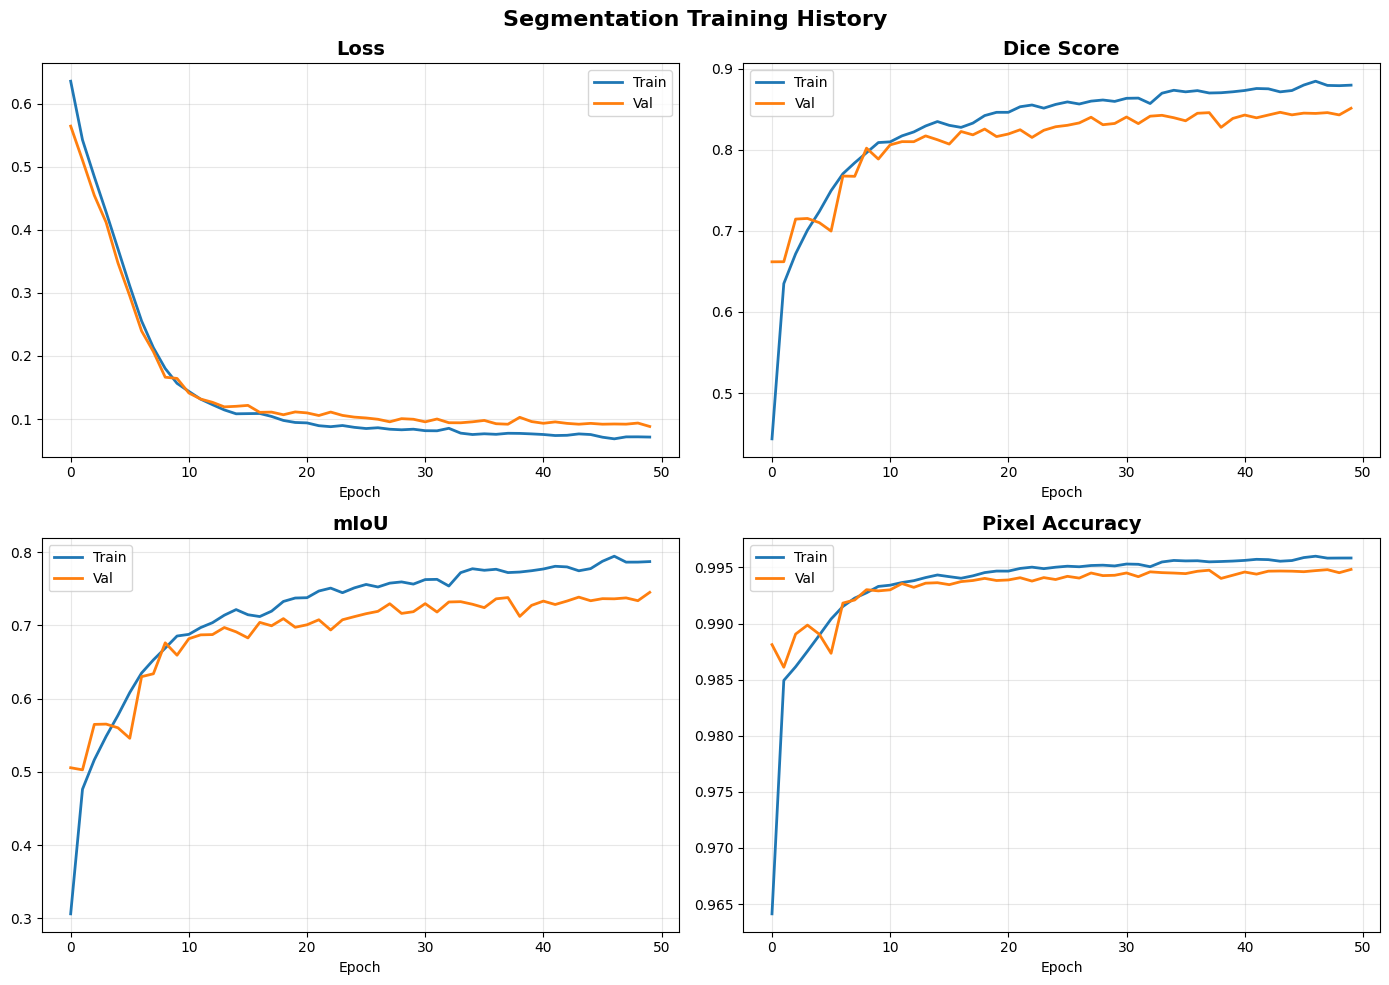

In [55]:
# =============================================================================
# PLOT SEGMENTATION TRAINING
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(unet_seg_history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(unet_seg_history['val_loss'], label='Val', linewidth=2)
axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Dice
axes[0, 1].plot(unet_seg_history['train_dice'], label='Train', linewidth=2)
axes[0, 1].plot(unet_seg_history['val_dice'], label='Val', linewidth=2)
axes[0, 1].set_title('Dice Score', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# mIoU
axes[1, 0].plot(unet_seg_history['train_miou'], label='Train', linewidth=2)
axes[1, 0].plot(unet_seg_history['val_miou'], label='Val', linewidth=2)
axes[1, 0].set_title('mIoU', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Pixel Accuracy
axes[1, 1].plot(unet_seg_history['train_pixel_acc'], label='Train', linewidth=2)
axes[1, 1].plot(unet_seg_history['val_pixel_acc'], label='Val', linewidth=2)
axes[1, 1].set_title('Pixel Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Segmentation Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Evaluate Segmentation

In [56]:
# =============================================================================
# EVALUATE SEGMENTATION
# =============================================================================

@torch.no_grad()
def evaluate_seg(model, loader, device, split_name):
    """Evaluate segmentation on a dataset split"""
    model.eval()
    all_metrics = {'dice': [], 'miou': [], 'pixel_acc': []}

    for batch in tqdm(loader, desc=f"Evaluating {split_name}", leave=False):
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        seg_logits = model(images)
        metrics = compute_seg_metrics(seg_logits, masks)

        for k, v in metrics.items():
            all_metrics[k].append(v)

    # Average
    avg_metrics = {k: np.mean(v) for k, v in all_metrics.items()}
    return avg_metrics

# Load best checkpoint
checkpoint = torch.load('unet_seg_best.pth')
unet_model.load_state_dict(checkpoint['model_state_dict'])

print("="*80)
print("SEGMENTATION EVALUATION")
print("="*80)

# Evaluate on all splits
results = []

for split_name, loader in [
    ('train', seg_train_loader),
    ('val', seg_val_loader),
    ('test', seg_test_loader)
]:
    metrics = evaluate_seg(unet_model, loader, config.DEVICE, split_name)

    results.append({
        'Split': split_name,
        'Dice': metrics['dice'],
        'mIoU': metrics['miou'],
        'Pixel Acc': metrics['pixel_acc']
    })

    print(f"\n{split_name.upper()}:")
    print(f"  Dice:      {metrics['dice']:.4f}")
    print(f"  mIoU:      {metrics['miou']:.4f}")
    print(f"  Pixel Acc: {metrics['pixel_acc']:.4f}")

# Save results
seg_results_df = pd.DataFrame(results)
seg_results_df.to_csv('segmentation_results.csv', index=False)

print(f"\n✓ Results saved to: segmentation_results.csv")
print("="*80)

# Display table
print("\nSegmentation Results:")
print(seg_results_df.to_string(index=False))

SEGMENTATION EVALUATION



TRAIN:
  Dice:      0.8835
  mIoU:      0.7935
  Pixel Acc: 0.9959



VAL:
  Dice:      0.8511
  mIoU:      0.7452
  Pixel Acc: 0.9948



TEST:
  Dice:      0.8553
  mIoU:      0.7551
  Pixel Acc: 0.9945

✓ Results saved to: segmentation_results.csv

Segmentation Results:
Split     Dice     mIoU  Pixel Acc
train 0.883480 0.793509   0.995918
  val 0.851119 0.745174   0.994826
 test 0.855262 0.755061   0.994513


## 6) TRAINING — CLASSIFICATION STAGE

### 6.1 Load Trained UNet & Create Classifier

In [57]:
# =============================================================================
# LOAD TRAINED UNET & CREATE CLASSIFIER
# =============================================================================

print("="*80)
print("CLASSIFICATION STAGE - USING UNET ENCODER FEATURES")
print("="*80)

# Load trained UNet from segmentation stage
checkpoint = torch.load('unet_seg_best.pth')
unet_model.load_state_dict(checkpoint['model_state_dict'])
unet_model.eval()  # Set to eval mode

print(f"✓ Loaded UNet checkpoint from epoch {checkpoint['epoch']}")
print(f"  Best Dice: {checkpoint['best_dice']:.4f}")

# Freeze UNet encoder (we'll only use it for feature extraction)
for param in unet_model.parameters():
    param.requires_grad = False

print(f"✓ Frozen UNet encoder (will use for feature extraction only)")

# Create classifier that operates on UNet encoder features
classifier_model = classifierhead(
    encoder_channels=config.BASE_CHANNELS * 16,  # 1024 channels
    num_classes=config.NUM_CLASSES_CLASSIFY,
    pretrained=True
).to(config.DEVICE)

print(f"✓ Created MobileNet-based classifier head")
print(f"  Pretrained: ImageNet weights")
print(f"  Input: UNet encoder features ({config.BASE_CHANNELS * 16} channels)")
print(f"  Output: {config.NUM_CLASSES_CLASSIFY} classes")

# Count parameters
classifier_params = sum(p.numel() for p in classifier_model.parameters() if p.requires_grad)
print(f"  Trainable parameters: {classifier_params:,}")
print("="*80)

CLASSIFICATION STAGE - USING UNET ENCODER FEATURES
✓ Loaded UNet checkpoint from epoch 49
  Best Dice: 0.8511
✓ Frozen UNet encoder (will use for feature extraction only)
✓ Created MobileNet-based classifier head
  Pretrained: ImageNet weights
  Input: UNet encoder features (1024 channels)
  Output: 4 classes
  Trainable parameters: 3,540,490


### 6.2 Classification Loss Function

In [58]:
# =============================================================================
# CLASSIFICATION LOSS
# =============================================================================

print("="*80)
print("CLASSIFICATION LOSS FUNCTION")
print("="*80)

# Use CrossEntropyLoss for multi-class classification
cls_criterion = nn.CrossEntropyLoss()

print("✓ Loss function: CrossEntropyLoss")
print("  For 4-class tumor classification")
print("  Classes: glioma, meningioma, pituitary, no tumor")
print("="*80)

CLASSIFICATION LOSS FUNCTION
✓ Loss function: CrossEntropyLoss
  For 4-class tumor classification
  Classes: glioma, meningioma, pituitary, no tumor


### 6.3 Epoch Functions (Cls Only)

In [59]:
# =============================================================================
# CLASSIFICATION TRAINING FUNCTIONS
# =============================================================================

def compute_cls_metrics(pred_logits, targets):
    """Compute classification metrics"""
    preds = torch.argmax(pred_logits, dim=1)

    # Move to CPU for sklearn
    preds_np = preds.cpu().numpy()
    targets_np = targets.cpu().numpy()

    # Metrics
    acc = accuracy_score(targets_np, preds_np)
    prec, rec, f1, _ = precision_recall_fscore_support(
        targets_np, preds_np, average='macro', zero_division=0
    )

    return {
        'acc': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

def train_epoch_cls(unet, classifier, loader, optimizer, criterion, device):
    """Train one epoch - classification using UNet encoder features"""
    unet.eval()  # UNet stays in eval mode (frozen)
    classifier.train()  # Only classifier trains
    
    total_loss = 0
    all_preds = []
    all_targets = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for batch in pbar:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        # Extract encoder features (no gradients for UNet)
        with torch.no_grad():
            encoder_features = unet.get_encoder_features(images)
        
        # Forward through classifier
        cls_logits = classifier(encoder_features)
        loss = criterion(cls_logits, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(cls_logits.detach())
        all_targets.append(labels)

        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    # Metrics
    avg_loss = total_loss / len(loader)
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    metrics = compute_cls_metrics(all_preds, all_targets)

    return avg_loss, metrics

@torch.no_grad()
def validate_epoch_cls(unet, classifier, loader, criterion, device):
    """Validate one epoch - classification using UNet encoder features"""
    unet.eval()
    classifier.eval()
    
    total_loss = 0
    all_preds = []
    all_targets = []

    pbar = tqdm(loader, desc="Validation", leave=False)

    for batch in pbar:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        # Extract encoder features
        encoder_features = unet.get_encoder_features(images)
        
        # Forward through classifier
        cls_logits = classifier(encoder_features)
        loss = criterion(cls_logits, labels)

        total_loss += loss.item()
        all_preds.append(cls_logits)
        all_targets.append(labels)

        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    # Metrics
    avg_loss = total_loss / len(loader)
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    metrics = compute_cls_metrics(all_preds, all_targets)

    return avg_loss, metrics

print("✓ Classification training functions defined")
print("  train_epoch_cls: uses UNet features + classifier")
print("  validate_epoch_cls: uses UNet features + classifier")
print("  Metrics: Accuracy, Precision, Recall, F1")

✓ Classification training functions defined
  train_epoch_cls: uses UNet features + classifier
  validate_epoch_cls: uses UNet features + classifier
  Metrics: Accuracy, Precision, Recall, F1


### 6.4 Train Classifier Head

In [60]:
# =============================================================================
# TRAIN CLASSIFICATION STAGE
# =============================================================================

print("="*80)
print("TRAINING CLASSIFICATION (STAGE 2)")
print("="*80)

# Optimizer (all parameters are trainable)
cls_optimizer = torch.optim.AdamW(
    classifier_model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)
cls_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cls_optimizer,
    mode='max',
    factor=0.5,
    patience=3,
    verbose=True
)

# Training history
unet_cls_history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': []
}

best_f1 = 0.0

print(f"\nTraining for {config.NUM_EPOCHS} epochs...")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Learning rate: {config.LEARNING_RATE}")
print()

# Training loop
for epoch in range(config.NUM_EPOCHS):
    # Train
    train_loss, train_metrics = train_epoch_cls(
        unet_model, classifier_model, cls_train_loader, cls_optimizer, cls_criterion, config.DEVICE
    )

    # Validate
    val_loss, val_metrics = validate_epoch_cls(
        unet_model, classifier_model, cls_val_loader, cls_criterion, config.DEVICE
    )

    # Update scheduler
    cls_scheduler.step(val_metrics['f1'])

    # Store history
    unet_cls_history['train_loss'].append(train_loss)
    unet_cls_history['val_loss'].append(val_loss)
    unet_cls_history['train_acc'].append(train_metrics['acc'])
    unet_cls_history['val_acc'].append(val_metrics['acc'])
    unet_cls_history['train_f1'].append(train_metrics['f1'])
    unet_cls_history['val_f1'].append(val_metrics['f1'])

    # Print
    print(f"Epoch {epoch+1}/{config.NUM_EPOCHS}")
    print(f"  Loss: {train_loss:.4f} / {val_loss:.4f}")
    print(f"  Acc:  {train_metrics['acc']:.4f} / {val_metrics['acc']:.4f}")
    print(f"  F1:   {train_metrics['f1']:.4f} / {val_metrics['f1']:.4f}")

    # Save best
    if val_metrics['f1'] > best_f1:
        best_f1 = val_metrics['f1']
        torch.save({
            'epoch': epoch,
            'model_state_dict': classifier_model.state_dict(),
            'best_f1': best_f1,
            'history': unet_cls_history
        }, 'classifier_best.pth')
        print(f"  ✓ Saved checkpoint (F1: {best_f1:.4f})")
    print()

print(f"\n✅ Classification training complete!")
print(f"   Best F1: {best_f1:.4f}")
print(f"   Checkpoint: unet_cls_best.pth")
print(f"   Checkpoint: classifier_best.pth")

TRAINING CLASSIFICATION (STAGE 2)

Training for 50 epochs...
Batch size: 8
Learning rate: 5e-05



Epoch 1/50
  Loss: 1.3471 / 1.1970
  Acc:  0.3425 / 0.4720
  F1:   0.3404 / 0.4311
  ✓ Saved checkpoint (F1: 0.4311)



Epoch 2/50
  Loss: 1.1727 / 1.0806
  Acc:  0.4803 / 0.5420
  F1:   0.4705 / 0.4792
  ✓ Saved checkpoint (F1: 0.4792)



Epoch 3/50
  Loss: 1.1133 / 1.0412
  Acc:  0.5175 / 0.5590
  F1:   0.5096 / 0.5022
  ✓ Saved checkpoint (F1: 0.5022)



Epoch 4/50
  Loss: 1.0398 / 0.9605
  Acc:  0.5530 / 0.6230
  F1:   0.5466 / 0.5865
  ✓ Saved checkpoint (F1: 0.5865)



...

Epoch 46/50
  Loss: 0.6915 / 0.8166
  Acc:  0.7345 / 0.7510
  F1:   0.7325 / 0.7393



Epoch 47/50
  Loss: 0.6886 / 0.7780
  Acc:  0.7268 / 0.7770
  F1:   0.7234 / 0.7665



Epoch 48/50
  Loss: 0.6916 / 0.8210
  Acc:  0.7290 / 0.7520
  F1:   0.7278 / 0.7423



Epoch 49/50
  Loss: 0.6834 / 0.7982
  Acc:  0.7305 / 0.7870
  F1:   0.7289 / 0.7818



Epoch 50/50
  Loss: 0.6905 / 0.8336
  Acc:  0.7368 / 0.7460
  F1:   0.7353 / 0.7293


✅ Classification training complete!
   Best F1: 0.8041
   Checkpoint: unet_cls_best.pth
   Checkpoint: classifier_best.pth


### 6.5 Plot Classification Training

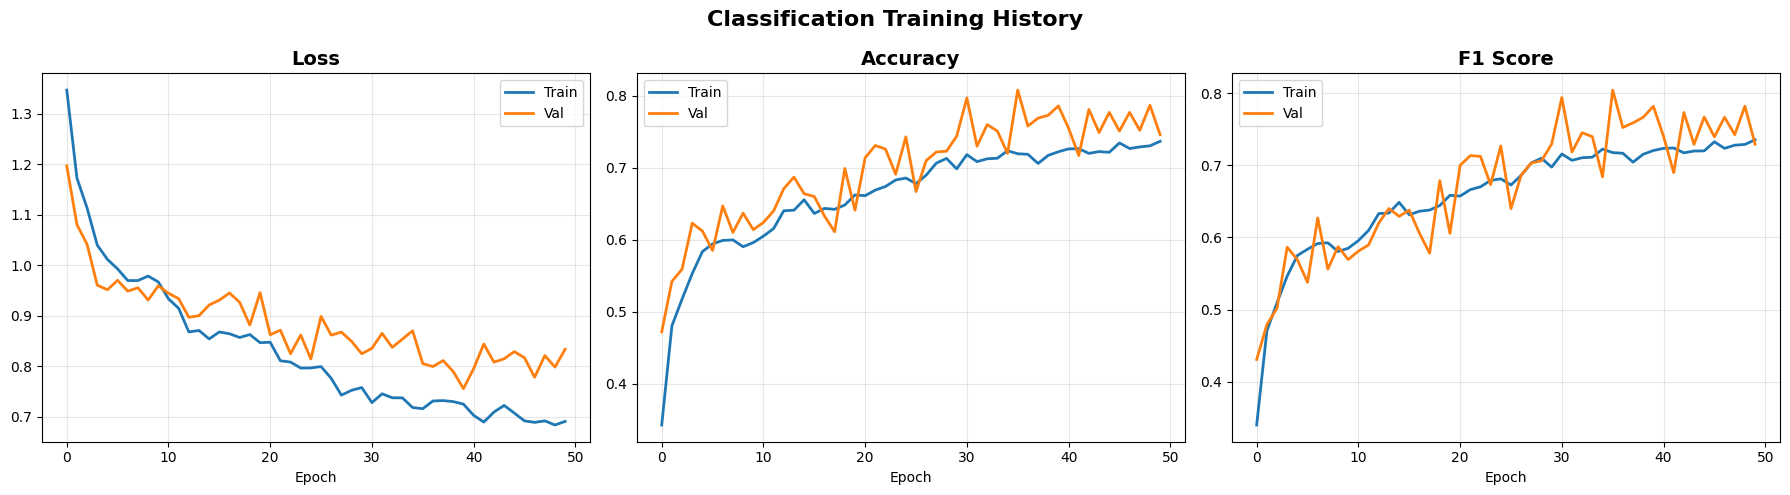

In [61]:
# =============================================================================
# PLOT CLASSIFICATION TRAINING
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(unet_cls_history['train_loss'], label='Train', linewidth=2)
axes[0].plot(unet_cls_history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(unet_cls_history['train_acc'], label='Train', linewidth=2)
axes[1].plot(unet_cls_history['val_acc'], label='Val', linewidth=2)
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

# F1
axes[2].plot(unet_cls_history['train_f1'], label='Train', linewidth=2)
axes[2].plot(unet_cls_history['val_f1'], label='Val', linewidth=2)
axes[2].set_title('F1 Score', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Classification Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7) EVALUATION — CLASSIFICATION

### 7.1 Evaluate Classification

In [62]:
# =============================================================================
# EVALUATE CLASSIFICATION
# =============================================================================

@torch.no_grad()
def evaluate_cls(unet, classifier, loader, device, split_name):
    """Evaluate classification using UNet encoder features"""
    unet.eval()
    classifier.eval()
    all_preds = []
    all_targets = []

    for batch in tqdm(loader, desc=f"Evaluating {split_name}", leave=False):
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        # Extract encoder features
        encoder_features = unet.get_encoder_features(images)
        
        # Forward through classifier
        cls_logits = classifier(encoder_features)

        all_preds.append(cls_logits)
        all_targets.append(labels)

    # Combine
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    # Metrics
    metrics = compute_cls_metrics(all_preds, all_targets)

    # Confusion matrix
    preds_np = torch.argmax(all_preds, dim=1).cpu().numpy()
    targets_np = all_targets.cpu().numpy()
    cm = confusion_matrix(targets_np, preds_np, labels=[0, 1, 2, 3])

    return metrics, cm

# Load best checkpoint
checkpoint = torch.load('classifier_best.pth')
classifier_model.load_state_dict(checkpoint['model_state_dict'])

print("="*80)
print("CLASSIFICATION EVALUATION")
print("="*80)

# Evaluate on all splits
results = []
confusion_matrices = {}

for split_name, loader in [
    ('train', cls_train_loader),
    ('val', cls_val_loader),
    ('test', cls_test_loader)
]:
    metrics, cm = evaluate_cls(unet_model, classifier_model, loader, config.DEVICE, split_name)

    results.append({
        'Split': split_name,
        'Accuracy': metrics['acc'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1': metrics['f1']
    })

    confusion_matrices[split_name] = cm

    print(f"\n{split_name.upper()}:")
    print(f"  Accuracy:  {metrics['acc']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1:        {metrics['f1']:.4f}")

# Save results
cls_results_df = pd.DataFrame(results)
cls_results_df.to_csv('classification_results.csv', index=False)

print(f"\n✓ Results saved to: classification_results.csv")
print("="*80)

# Display table
print("\nClassification Results:")
print(cls_results_df.to_string(index=False))

CLASSIFICATION EVALUATION



TRAIN:
  Accuracy:  0.8073
  Precision: 0.8285
  Recall:    0.7994
  F1:        0.8027



VAL:
  Accuracy:  0.8080
  Precision: 0.8399
  Recall:    0.7983
  F1:        0.8041



TEST:
  Accuracy:  0.7850
  Precision: 0.8222
  Recall:    0.7923
  F1:        0.7856

✓ Results saved to: classification_results.csv

Classification Results:
Split  Accuracy  Precision   Recall       F1
train   0.80725   0.828491 0.799365 0.802684
  val   0.80800   0.839911 0.798321 0.804125
 test   0.78500   0.822191 0.792305 0.785646


### 7.2 Confusion Matrices

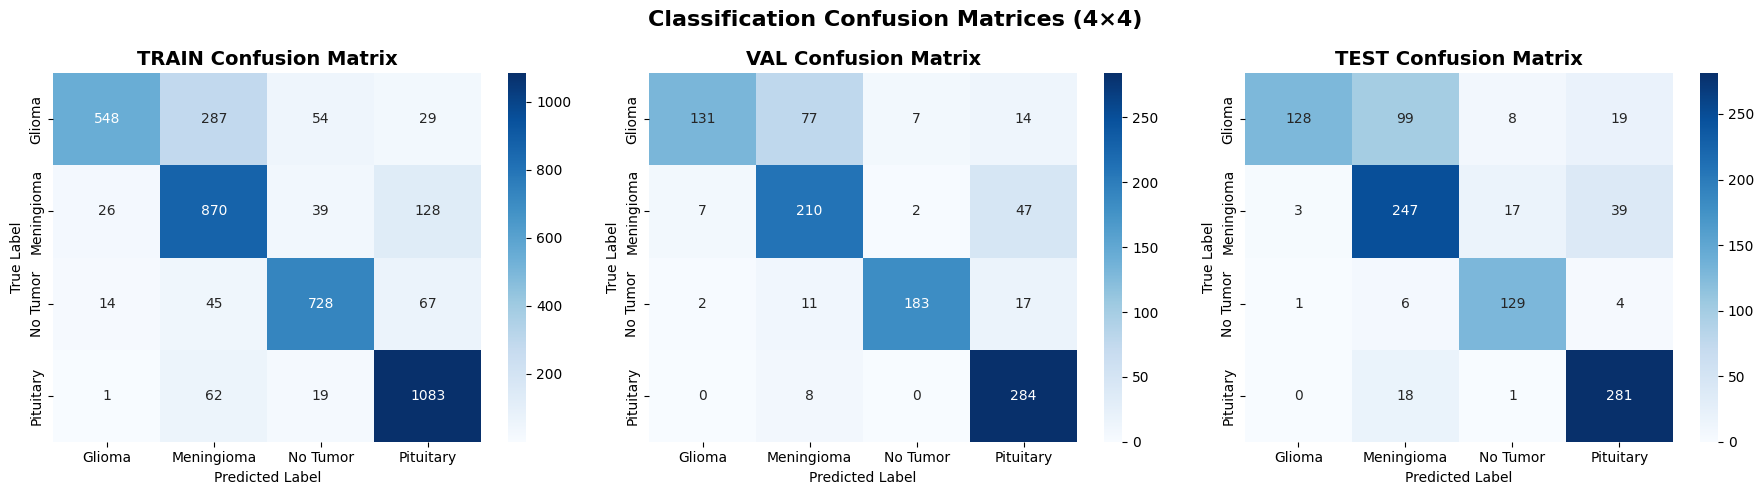


VERIFICATION: No Tumor Class
✓ TRAIN: No Tumor has 854 samples
✓ VAL: No Tumor has 213 samples
✓ TEST: No Tumor has 140 samples


In [63]:
# =============================================================================
# PLOT CONFUSION MATRICES
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (split_name, cm) in enumerate(confusion_matrices.items()):
    ax = axes[idx]

    # Plot
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=config.CLASS_NAMES,
        yticklabels=config.CLASS_NAMES,
        ax=ax
    )

    ax.set_title(f'{split_name.upper()} Confusion Matrix', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Classification Confusion Matrices (4×4)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Verify No Tumor is present
print("\n" + "="*80)
print("VERIFICATION: No Tumor Class")
print("="*80)

for split_name, cm in confusion_matrices.items():
    no_tumor_samples = cm[2, :].sum()  # Row 2 = No Tumor
    status = "✓" if no_tumor_samples > 0 else "❌"
    print(f"{status} {split_name.upper()}: No Tumor has {no_tumor_samples} samples")

print("="*80)

## 8) FINAL REPORTING / EXPORT

### 8.1 Summary

In [64]:
# =============================================================================
# PROJECT SUMMARY
# =============================================================================

import os

print("="*80)
print("PROJECT SUMMARY")
print("="*80)

print("\n📊 DATASETS:")
print(f"  Segmentation:")
print(f"    Train:  {len(seg_train_dataset)} images")
print(f"    Val:    {len(seg_val_dataset)} images")
print(f"    Test:   {len(seg_test_dataset)} images")
print(f"  Classification:")
print(f"    Train:  {len(cls_train_dataset)} images")
print(f"    Val:    {len(cls_val_dataset)} images")
print(f"    Test:   {len(cls_test_dataset)} images")

print("\n🏗️ MODEL ARCHITECTURE:")
print(f"  Input: Grayscale ({config.IN_CHANNELS} channel)")
print(f"  Encoder: 5 levels")
print(f"  Segmentation head: Conv → sigmoid")
print(f"  Classification head: GAP → MLP (4 classes)")
print(f"  Total parameters: {total_params:,}")

print("\n🎯 TRAINING:")
print(f"  Stage 1 (Segmentation):")
print(f"    Epochs: {config.NUM_EPOCHS}")
print(f"    Best Dice: {best_dice:.4f}")
print(f"  Stage 2 (Classification):")
print(f"    Epochs: {config.NUM_EPOCHS}")
print(f"    Best F1: {best_f1:.4f}")

print("\n📁 OUTPUT FILES:")
files = [
    'unet_seg_best.pth',
    'unet_cls_best.pth',
    'segmentation_results.csv',
    'classification_results.csv'
]

for fname in files:
    exists = os.path.exists(fname)
    status = "✓" if exists else "❌"
    print(f"  {status} {fname}")

print("="*80)
print("✅ NOTEBOOK EXECUTION COMPLETE!")
print("="*80)

PROJECT SUMMARY

📊 DATASETS:
  Segmentation:
    Train:  3146 images
    Val:    787 images
    Test:   860 images
  Classification:
    Train:  4000 images
    Val:    1000 images
    Test:   1000 images

🏗️ MODEL ARCHITECTURE:
  Input: Grayscale (1 channel)
  Encoder: 5 levels
  Segmentation head: Conv → sigmoid
  Classification head: GAP → MLP (4 classes)
  Total parameters: 31,036,546

🎯 TRAINING:
  Stage 1 (Segmentation):
    Epochs: 50
    Best Dice: 0.8511
  Stage 2 (Classification):
    Epochs: 50
    Best F1: 0.8041

📁 OUTPUT FILES:
  ✓ unet_seg_best.pth
  ❌ unet_cls_best.pth
  ✓ segmentation_results.csv
  ✓ classification_results.csv
✅ NOTEBOOK EXECUTION COMPLETE!


### 8.2 Artifacts to Save

**Checkpoint Files:**
- `unet_seg_best.pth` - Segmentation model (best Dice)
- `unet_cls_best.pth` - Classification model (best F1)

**Results Files:**
- `segmentation_results.csv` - Seg metrics (train/val/test)
- `classification_results.csv` - Cls metrics (train/val/test)

**All files can be downloaded from the Colab environment.**

## 9) ATTENTION U-NET ARCHITECTURE

Enhanced U-Net with **Attention Gates** for improved segmentation:
-  Attention mechanism focuses on relevant spatial regions
-  Better boundary detection and small object segmentation
-  Minimal parameter overhead compared to regular U-Net

**Components:**
1. **AttentionGate**: Learns spatial attention coefficients
2. **AttentionUp**: Combines upsampling + attention + convolution
3. **AttentionUNet**: Full encoder-decoder with attention gates

In [65]:
# =============================================================================
# ATTENTION U-NET ARCHITECTURE
# =============================================================================

class AttentionGate(nn.Module):
    """
    Attention Gate module for Attention U-Net.
    
    Learns to focus on relevant spatial regions by generating attention coefficients.
    Suppresses irrelevant features and highlights salient features.
    """
    def __init__(self, F_g, F_l, F_int):
        """
        Args:
            F_g: Number of feature channels from gating signal (decoder)
            F_l: Number of feature channels from encoder skip connection
            F_int: Number of intermediate feature channels
        """
        super(AttentionGate, self).__init__()

        # Transform gating signal
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        # Transform encoder features
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        # Generate attention coefficients
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        """
        Args:
            g: Gating signal from decoder (coarse features)
            x: Encoder features (fine features)
        Returns:
            Attention-weighted encoder features
        """
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi  # Element-wise multiplication


class AttentionUp(nn.Module):
    """
    Upsampling with Attention Gate followed by DoubleConv.
    
    Combines upsampled decoder features with attention-weighted encoder features.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.attention = AttentionGate(
            F_g=in_channels // 2,    # Decoder features
            F_l=in_channels // 2,    # Encoder features
            F_int=in_channels // 4   # Intermediate channels
        )
        self.conv = DoubleConv(in_channels, out_channels)

    @staticmethod
    def _pad_to_match(x1, x2):
        """Pad x1 to match x2 dimensions"""
        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)

        return F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2]
        )

    def forward(self, x_decoder, x_encoder):
        """
        Args:
            x_decoder: Decoder features (from previous layer)
            x_encoder: Encoder features (skip connection)
        Returns:
            Concatenated and processed features
        """
        # Upsample decoder features
        x_decoder = self.up(x_decoder)

        # Apply attention gate
        x_encoder = self.attention(g=x_decoder, x=x_encoder)

        # Pad if needed
        x_decoder = self._pad_to_match(x_decoder, x_encoder)

        # Concatenate and process
        x = torch.cat([x_encoder, x_decoder], dim=1)
        return self.conv(x)


class AttentionUNet(nn.Module):
    """
    Attention U-Net for improved segmentation.
    
    Adds attention gates to standard U-Net to focus on relevant features.
    Better performance on small/sparse objects and boundary detection.
    """
    def __init__(
        self,
        in_channels: int = 1,
        num_classes: int = 1,
        base_channels: int = 64
    ):
        super(AttentionUNet, self).__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = Down(base_channels, base_channels * 2)
        self.enc3 = Down(base_channels * 2, base_channels * 4)
        self.enc4 = Down(base_channels * 4, base_channels * 8)
        self.enc5 = Down(base_channels * 8, base_channels * 16)

        # Decoder with Attention
        self.dec1 = AttentionUp(base_channels * 16, base_channels * 8)
        self.dec2 = AttentionUp(base_channels * 8, base_channels * 4)
        self.dec3 = AttentionUp(base_channels * 4, base_channels * 2)
        self.dec4 = AttentionUp(base_channels * 2, base_channels)

        # Output
        self.out = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder path
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)
        x5 = self.enc5(x4)

        # Decoder path with attention
        x = self.dec1(x5, x4)
        x = self.dec2(x, x3)
        x = self.dec3(x, x2)
        x = self.dec4(x, x1)

        # Output
        return self.out(x)

    def get_encoder_features(self, x):
        """Extract deep encoder features for classification"""
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)
        x5 = self.enc5(x4)
        return x5


print("✓ Attention U-Net architecture defined")
print("  Components: AttentionGate + AttentionUp modules")
print("  Encoder: 5 levels (same as U-Net)")
print("  Decoder: 4 levels with attention gates")
print("  Output: Conv → logits (segmentation only)")
print("  Benefits: Better boundary detection + focus on relevant features")

✓ Attention U-Net architecture defined
  Components: AttentionGate + AttentionUp modules
  Encoder: 5 levels (same as U-Net)
  Decoder: 4 levels with attention gates
  Output: Conv → logits (segmentation only)
  Benefits: Better boundary detection + focus on relevant features


In [66]:
# =============================================================================
# TEST ATTENTION U-NET
# =============================================================================

# Create Attention U-Net
test_attn_unet = AttentionUNet(
    in_channels=config.IN_CHANNELS,
    num_classes=config.NUM_CLASSES_SEG,
    base_channels=config.BASE_CHANNELS
).eval().to(config.DEVICE)

# Test forward pass
test_input = torch.randn(2, config.IN_CHANNELS, config.IMAGE_SIZE, config.IMAGE_SIZE).to(config.DEVICE)
seg_out = test_attn_unet(test_input)

print("="*80)
print("ATTENTION U-NET TEST")
print("="*80)
print(f"Input shape:  {test_input.shape}")
print(f"Seg output:   {seg_out.shape} (expected: [B, 1, H, W])")

# Count parameters
total_params = sum(p.numel() for p in test_attn_unet.parameters())
trainable_params = sum(p.numel() for p in test_attn_unet.parameters() if p.requires_grad)
regular_unet_params = 31037633  # Approximate for comparison

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Regular U-Net params: ~{regular_unet_params:,}")
print(f"Attention overhead: ~{total_params - regular_unet_params:,} params")
print("\n✓ Attention gates add minimal parameters but improve performance")
print("="*80)

# Clean up
del test_attn_unet, test_input, seg_out
torch.cuda.empty_cache() if torch.cuda.is_available() else None

ATTENTION U-NET TEST
Input shape:  torch.Size([2, 1, 256, 256])
Seg output:   torch.Size([2, 2, 256, 256]) (expected: [B, 1, H, W])

Total parameters: 31,388,078
Trainable parameters: 31,388,078
Regular U-Net params: ~31,037,633
Attention overhead: ~350,445 params

✓ Attention gates add minimal parameters but improve performance


In [67]:
# =============================================================================
# TEST ATTENTION UNET + CLASSIFIER PIPELINE
# =============================================================================

# Create AttentionUNet (for encoder features)
test_att_unet = AttentionUNet(
    in_channels=config.IN_CHANNELS,
    num_classes=config.NUM_CLASSES_SEG,
    base_channels=config.BASE_CHANNELS
).eval().to(config.DEVICE)

# Create classifier
test_att_classifier = classifierhead(
    encoder_channels=config.BASE_CHANNELS * 16,  # 64 * 16 = 1024
    num_classes=config.NUM_CLASSES_CLASSIFY,
    pretrained=True
).eval().to(config.DEVICE)

# Test forward pass
test_att_input = torch.randn(2, config.IN_CHANNELS, config.IMAGE_SIZE, config.IMAGE_SIZE).to(config.DEVICE)

# Extract encoder features
encoder_features = test_att_unet.get_encoder_features(test_att_input)

# Classify using encoder features
cls_att_out = test_att_classifier(encoder_features)

print("="*80)
print("Attention UNET + CLASSIFIER PIPELINE TEST")
print("="*80)
print(f"Input shape:           {test_att_input.shape}")
print(f"Encoder features:      {encoder_features.shape}")
print(f"Classification output: {cls_att_out.shape} (expected: [B, 4])")

# Count parameters

unet_params = sum(p.numel() for p in test_att_unet.parameters())
# Free GPU memory if available (no-op on CPU)
torch.cuda.empty_cache() if torch.cuda.is_available() else None

classifier_params = sum(p.numel() for p in test_att_classifier.parameters())
# Clean up temporary objects to reduce memory pressure
del test_att_unet, test_att_classifier, test_att_input, encoder_features, cls_att_out

print(f"\nParameters:")
print(f"  UNet encoder+decoder: {unet_params:,}")
print("="*80)
print(f"  Classifier head:      {classifier_params:,}")
print(f"\n✓ Pipeline: Image → UNet Encoder → Features → Classifier → Class")
print(f"  Total:                {unet_params + classifier_params:,}")

Attention UNET + CLASSIFIER PIPELINE TEST
Input shape:           torch.Size([2, 1, 256, 256])
Encoder features:      torch.Size([2, 1024, 16, 16])
Classification output: torch.Size([2, 4]) (expected: [B, 4])

Parameters:
  UNet encoder+decoder: 31,388,078
  Classifier head:      3,540,490

✓ Pipeline: Image → UNet Encoder → Features → Classifier → Class
  Total:                34,928,568


## 10) ATTENTION U-NET TRAINING

Train Attention U-Net for **segmentation** task:
-  Same training pipeline as regular U-Net
-  DiceBCE loss, AdamW optimizer, ReduceLROnPlateau scheduler
-  Save best model based on validation Dice score

**Sections:**
- 10.1 Training Loop
- 10.2 Visualization
- 10.3 Evaluation

In [68]:
# =============================================================================
# TRAIN ATTENTION U-NET FOR SEGMENTATION
# =============================================================================

print("="*80)
print("TRAINING ATTENTION U-NET (ENHANCED SEGMENTATION)")
print("="*80)

# Create Attention U-Net model
attention_unet_model = AttentionUNet(
    in_channels=config.IN_CHANNELS,
    num_classes=config.NUM_CLASSES_SEG,
    base_channels=config.BASE_CHANNELS
).to(config.DEVICE)

print(f"\n✓ Model created:")
print(f"  Architecture: Attention U-Net (with attention gates)")
print(f"  Input channels: {config.IN_CHANNELS}")
print(f"  Output classes: {config.NUM_CLASSES_SEG}")
print(f"  Base channels: {config.BASE_CHANNELS}")
print(f"  Device: {config.DEVICE}\n")

# Loss and optimizer
attn_seg_criterion = DiceBCELoss(dice_weight=0.5, bce_weight=0.5)
attn_seg_optimizer = torch.optim.AdamW(
    attention_unet_model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)
attn_seg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    attn_seg_optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    
)

# Training history
attn_seg_history = {
    'train_loss': [], 'val_loss': [],
    'train_dice': [], 'val_dice': [],
    'train_miou': [], 'val_miou': [],
    'train_pixel_acc': [], 'val_pixel_acc': []
}

best_attn_dice = 0.0

print(f"\nTraining for {config.NUM_EPOCHS} epochs...")
print(f"Device: {config.DEVICE}")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Learning rate: {config.LEARNING_RATE}")
print()

# Training loop
for epoch in range(config.NUM_EPOCHS):
    # Train
    train_loss, train_metrics = train_epoch_seg(
        attention_unet_model, seg_train_loader, attn_seg_optimizer, attn_seg_criterion, config.DEVICE
    )

    # Validate
    val_loss, val_metrics = validate_epoch_seg(
        attention_unet_model, seg_val_loader, attn_seg_criterion, config.DEVICE
    )

    # Update scheduler
    attn_seg_scheduler.step(val_metrics['dice'])

    # Store history
    attn_seg_history['train_loss'].append(train_loss)
    attn_seg_history['val_loss'].append(val_loss)
    attn_seg_history['train_dice'].append(train_metrics['dice'])
    attn_seg_history['val_dice'].append(val_metrics['dice'])
    attn_seg_history['train_miou'].append(train_metrics['miou'])
    attn_seg_history['val_miou'].append(val_metrics['miou'])
    attn_seg_history['train_pixel_acc'].append(train_metrics['pixel_acc'])
    attn_seg_history['val_pixel_acc'].append(val_metrics['pixel_acc'])

    # Print
    print(f"Epoch {epoch+1}/{config.NUM_EPOCHS}")
    print(f"  Loss: {train_loss:.4f} / {val_loss:.4f}")
    print(f"  Dice: {train_metrics['dice']:.4f} / {val_metrics['dice']:.4f}")
    print(f"  mIoU: {train_metrics['miou']:.4f} / {val_metrics['miou']:.4f}")
    print(f"  Pixel Acc: {train_metrics['pixel_acc']:.4f} / {val_metrics['pixel_acc']:.4f}")

    # Save best
    if val_metrics['dice'] > best_attn_dice:
        best_attn_dice = val_metrics['dice']
        torch.save({
            'epoch': epoch,
            'model_state_dict': attention_unet_model.state_dict(),
            'optimizer_state_dict': attn_seg_optimizer.state_dict(),
            'best_dice': best_attn_dice,
            'history': attn_seg_history
        }, 'attention_unet_seg_best.pth')
        print(f"  ✓ Saved checkpoint (Dice: {best_attn_dice:.4f})")
    print()


print(f"\n✅ Attention U-Net training complete!")
print("="*80)
print(f"   Best Dice: {best_attn_dice:.4f}")
print(f"   Checkpoint: attention_unet_seg_best.pth")
print("="*80)

TRAINING ATTENTION U-NET (ENHANCED SEGMENTATION)

✓ Model created:
  Architecture: Attention U-Net (with attention gates)
  Input channels: 1
  Output classes: 2
  Base channels: 64
  Device: cuda


Training for 50 epochs...
Device: cuda
Batch size: 8
Learning rate: 5e-05



Epoch 1/50
  Loss: 0.6172 / 0.5568
  Dice: 0.4616 / 0.6511
  mIoU: 0.3226 / 0.4958
  Pixel Acc: 0.9724 / 0.9876
  ✓ Saved checkpoint (Dice: 0.6511)



Epoch 2/50
  Loss: 0.5312 / 0.5028
  Dice: 0.6314 / 0.6607
  mIoU: 0.4738 / 0.5020
  Pixel Acc: 0.9846 / 0.9860
  ✓ Saved checkpoint (Dice: 0.6607)



Epoch 3/50
  Loss: 0.4724 / 0.4409
  Dice: 0.6723 / 0.6879
  mIoU: 0.5165 / 0.5329
  Pixel Acc: 0.9862 / 0.9869
  ✓ Saved checkpoint (Dice: 0.6879)



Epoch 4/50
  Loss: 0.4147 / 0.3777
  Dice: 0.7045 / 0.7401
  mIoU: 0.5536 / 0.5960
  Pixel Acc: 0.9878 / 0.9901
  ✓ Saved checkpoint (Dice: 0.7401)



...

Epoch 46/50
  Loss: 0.0669 / 0.0905
  Dice: 0.8870 / 0.8471
  mIoU: 0.7987 / 0.7398
  Pixel Acc: 0.9961 / 0.9948



Epoch 47/50
  Loss: 0.0669 / 0.0888
  Dice: 0.8870 / 0.8501
  mIoU: 0.7988 / 0.7444
  Pixel Acc: 0.9961 / 0.9948



Epoch 48/50
  Loss: 0.0664 / 0.0841
  Dice: 0.8877 / 0.8588
  mIoU: 0.8000 / 0.7565
  Pixel Acc: 0.9962 / 0.9951
  ✓ Saved checkpoint (Dice: 0.8588)



Epoch 49/50
  Loss: 0.0665 / 0.0861
  Dice: 0.8876 / 0.8550
  mIoU: 0.7996 / 0.7512
  Pixel Acc: 0.9961 / 0.9950



Epoch 50/50
  Loss: 0.0646 / 0.0860
  Dice: 0.8908 / 0.8552
  mIoU: 0.8046 / 0.7515
  Pixel Acc: 0.9962 / 0.9951


✅ Attention U-Net training complete!
   Best Dice: 0.8588
   Checkpoint: attention_unet_seg_best.pth


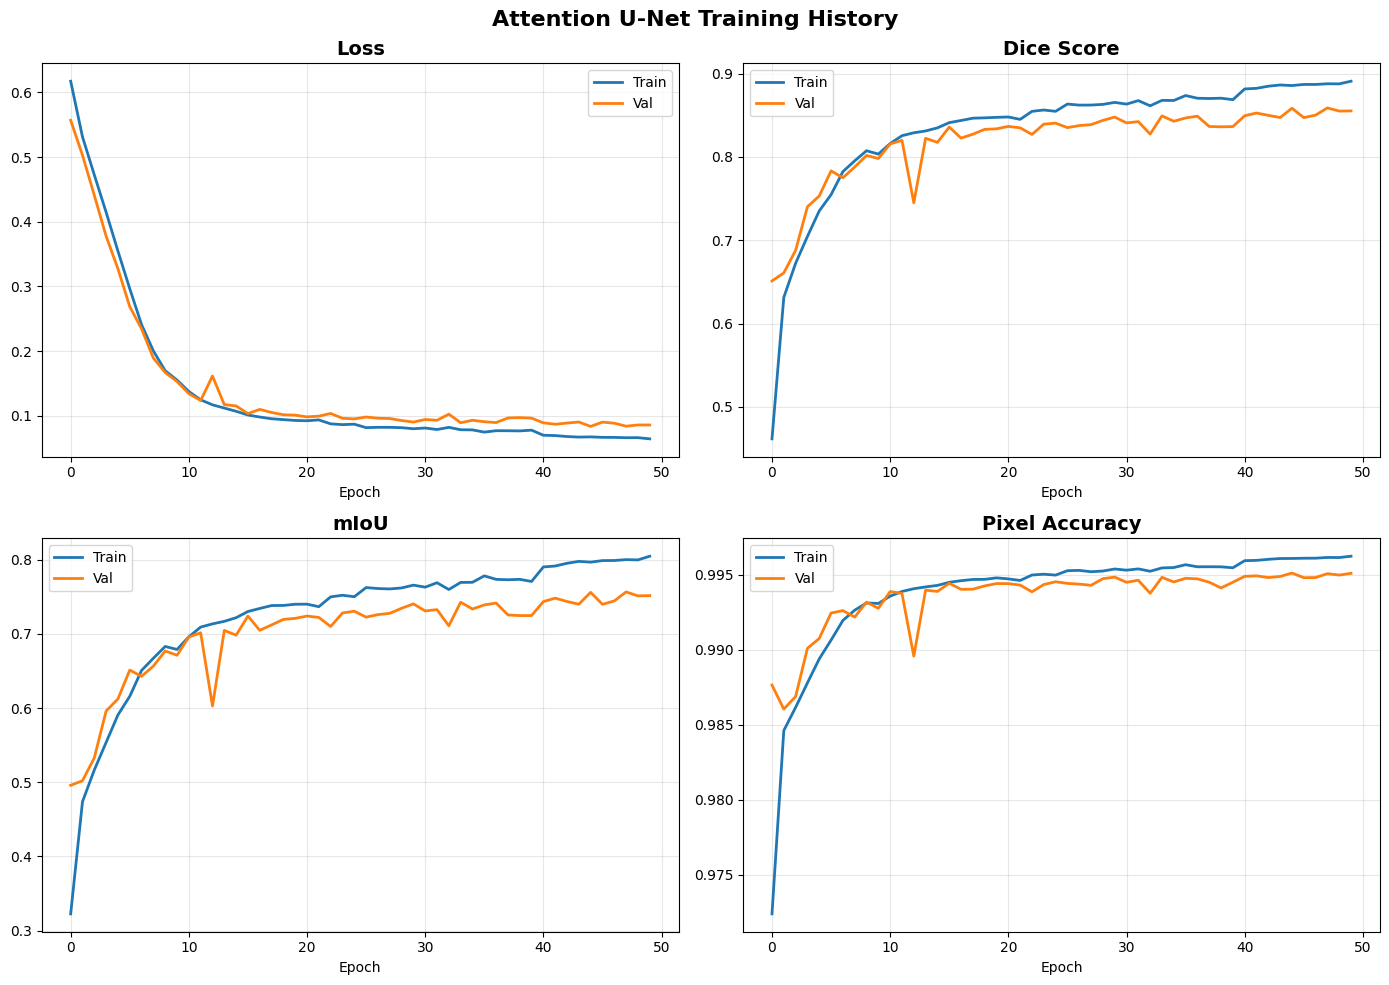

In [69]:
# =============================================================================
# PLOT ATTENTION U-NET TRAINING
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(attn_seg_history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(attn_seg_history['val_loss'], label='Val', linewidth=2)
axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Dice
axes[0, 1].plot(attn_seg_history['train_dice'], label='Train', linewidth=2)
axes[0, 1].plot(attn_seg_history['val_dice'], label='Val', linewidth=2)
axes[0, 1].set_title('Dice Score', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# mIoU
axes[1, 0].plot(attn_seg_history['train_miou'], label='Train', linewidth=2)
axes[1, 0].plot(attn_seg_history['val_miou'], label='Val', linewidth=2)
axes[1, 0].set_title('mIoU', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Pixel Accuracy
axes[1, 1].plot(attn_seg_history['train_pixel_acc'], label='Train', linewidth=2)
axes[1, 1].plot(attn_seg_history['val_pixel_acc'], label='Val', linewidth=2)
axes[1, 1].set_title('Pixel Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Attention U-Net Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:
# =============================================================================
# EVALUATE ATTENTION U-NET
# =============================================================================

# Load best checkpoint
attn_checkpoint = torch.load('attention_unet_seg_best.pth')
attention_unet_model.load_state_dict(attn_checkpoint['model_state_dict'])

print("="*80)
print("ATTENTION U-NET EVALUATION")
print("="*80)

# Evaluate on all splits
attn_results = []

for split_name, loader in [
    ('train', seg_train_loader),
    ('val', seg_val_loader),
    ('test', seg_test_loader)
]:
    metrics = evaluate_seg(attention_unet_model, loader, config.DEVICE, split_name)

    attn_results.append({
        'Split': split_name,
        'Dice': metrics['dice'],
        'mIoU': metrics['miou'],
        'Pixel Acc': metrics['pixel_acc']
    })

    print(f"\n{split_name.upper()}:")
    print(f"  Dice:      {metrics['dice']:.4f}")
    print(f"  mIoU:      {metrics['miou']:.4f}")
    print(f"  Pixel Acc: {metrics['pixel_acc']:.4f}")

# Save results
attn_seg_results_df = pd.DataFrame(attn_results)
attn_seg_results_df.to_csv('attention_unet_results.csv', index=False)

print(f"\n✓ Results saved to: attention_unet_results.csv")
print("="*80)

# Display table
print("\nAttention U-Net Results:")
print(attn_seg_results_df.to_string(index=False))

ATTENTION U-NET EVALUATION



TRAIN:
  Dice:      0.8901
  mIoU:      0.8038
  Pixel Acc: 0.9961



VAL:
  Dice:      0.8588
  mIoU:      0.7565
  Pixel Acc: 0.9951



TEST:
  Dice:      0.8562
  mIoU:      0.7570
  Pixel Acc: 0.9947

✓ Results saved to: attention_unet_results.csv

Attention U-Net Results:
Split     Dice     mIoU  Pixel Acc
train 0.890082 0.803823   0.996083
  val 0.858775 0.756463   0.995071
 test 0.856155 0.756968   0.994697


## 11) CLASSIFICATION WITH ATTENTION U-NET

Use **Attention U-Net encoder** features for tumor classification:
-  Freeze trained Attention U-Net encoder weights
-  Train only the classifier head (4 tumor types)
-  Compare with regular U-Net classifier

**Sections:**
- 11.1 Load & Freeze Attention U-Net
- 11.2 Train Classifier
- 11.3 Evaluate & Compare
- 11.4 Model Comparison (U-Net vs Attention U-Net)

In [71]:
# Load trained Attention U-Net for feature extraction
print("Loading trained Attention U-Net...")
attention_unet_loaded = AttentionUNet(
    in_channels=config.IN_CHANNELS,      # Should be 1 for grayscale
    num_classes=config.NUM_CLASSES_SEG,  # Should be 1 or 2 for binary segmentation
    base_channels=config.BASE_CHANNELS   # Should match training config
).to(config.DEVICE)

attention_unet_loaded.load_state_dict(torch.load('attention_unet_seg_best.pth')['model_state_dict'])
attention_unet_loaded.eval()

# Freeze all Attention U-Net parameters
for param in attention_unet_loaded.parameters():
    param.requires_grad = False

print(f"Attention U-Net loaded and frozen. Total parameters: {sum(p.numel() for p in attention_unet_loaded.parameters()):,}")

# Create classifier head
attention_classifier = classifierhead(num_classes=config.NUM_CLASSES_CLASSIFY).to(config.DEVICE)
print(f"Classifier created with {sum(p.numel() for p in attention_classifier.parameters()):,} parameters")

# Optimizer and loss for classifier only
cls_optimizer_attn = torch.optim.AdamW(attention_classifier.parameters(), lr=1e-4, weight_decay=1e-4)
cls_criterion = nn.CrossEntropyLoss()

print("\nReady to train classifier with Attention U-Net encoder features!")

Loading trained Attention U-Net...
Attention U-Net loaded and frozen. Total parameters: 31,388,078
Classifier created with 3,540,490 parameters

Ready to train classifier with Attention U-Net encoder features!


In [72]:
# Train classifier with Attention U-Net encoder features
best_val_f1_attn = 0.0

attn_cls_history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

print("="*60)
print("Training Classifier with Attention U-Net Encoder Features")
print("="*60)

for epoch in range(config.NUM_EPOCHS):
    # Train - returns (loss, metrics_dict)
    train_loss, train_metrics = train_epoch_cls(
        attention_unet_loaded, attention_classifier, cls_train_loader, 
        cls_optimizer_attn, cls_criterion, config.DEVICE
    )
    
    # Validate - returns (loss, metrics_dict)
    val_loss, val_metrics = validate_epoch_cls(
        attention_unet_loaded, attention_classifier, cls_val_loader, 
        cls_criterion, config.DEVICE
    )
    
    # Extract individual metrics from dictionary
    train_acc = train_metrics['acc'] * 100  # Convert to percentage
    train_f1 = train_metrics['f1']
    val_acc = val_metrics['acc'] * 100      # Convert to percentage
    val_f1 = val_metrics['f1']
    
    # Record history
    attn_cls_history['train_loss'].append(train_loss)
    attn_cls_history['train_acc'].append(train_acc)
    attn_cls_history['train_f1'].append(train_f1)
    attn_cls_history['val_loss'].append(val_loss)
    attn_cls_history['val_acc'].append(val_acc)
    attn_cls_history['val_f1'].append(val_f1)
    
    # Save best model
    if val_f1 > best_val_f1_attn:
        best_val_f1_attn = val_f1
        torch.save(attention_classifier.state_dict(), 'attention_classifier_best.pth')
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{config.NUM_EPOCHS}]")
        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%, F1: {train_f1:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, F1: {val_f1:.4f}")

print("\n" + "="*60)
print(f"Training Complete! Best Val F1: {best_val_f1_attn:.4f}")
print("="*60)

Training Classifier with Attention U-Net Encoder Features


Epoch [1/50]
  Train - Loss: 1.3198, Acc: 36.70%, F1: 0.3561
  Val   - Loss: 1.3866, Acc: 28.70%, F1: 0.2207


Epoch [5/50]
  Train - Loss: 0.9289, Acc: 62.82%, F1: 0.6221
  Val   - Loss: 1.0070, Acc: 61.10%, F1: 0.6077


Epoch [10/50]
  Train - Loss: 0.8622, Acc: 63.05%, F1: 0.6238
  Val   - Loss: 0.8767, Acc: 71.90%, F1: 0.7021


Epoch [15/50]
  Train - Loss: 0.6973, Acc: 73.02%, F1: 0.7285
  Val   - Loss: 0.8371, Acc: 79.50%, F1: 0.7849


...

Epoch [30/50]
  Train - Loss: 0.3818, Acc: 86.60%, F1: 0.8660
  Val   - Loss: 0.5543, Acc: 86.60%, F1: 0.8612


Epoch [35/50]
  Train - Loss: 0.3222, Acc: 88.78%, F1: 0.8885
  Val   - Loss: 0.4765, Acc: 86.70%, F1: 0.8629


Epoch [40/50]
  Train - Loss: 0.2819, Acc: 91.22%, F1: 0.9126
  Val   - Loss: 0.3787, Acc: 92.70%, F1: 0.9252


Epoch [45/50]
  Train - Loss: 0.2113, Acc: 93.27%, F1: 0.9326
  Val   - Loss: 0.2466, Acc: 96.00%, F1: 0.9607


Epoch [50/50]
  Train - Loss: 0.2029, Acc: 93.80%, F1: 0.9380
  Val   - Loss: 0.3434, Acc: 96.40%, F1: 0.9639

Training Complete! Best Val F1: 0.9639


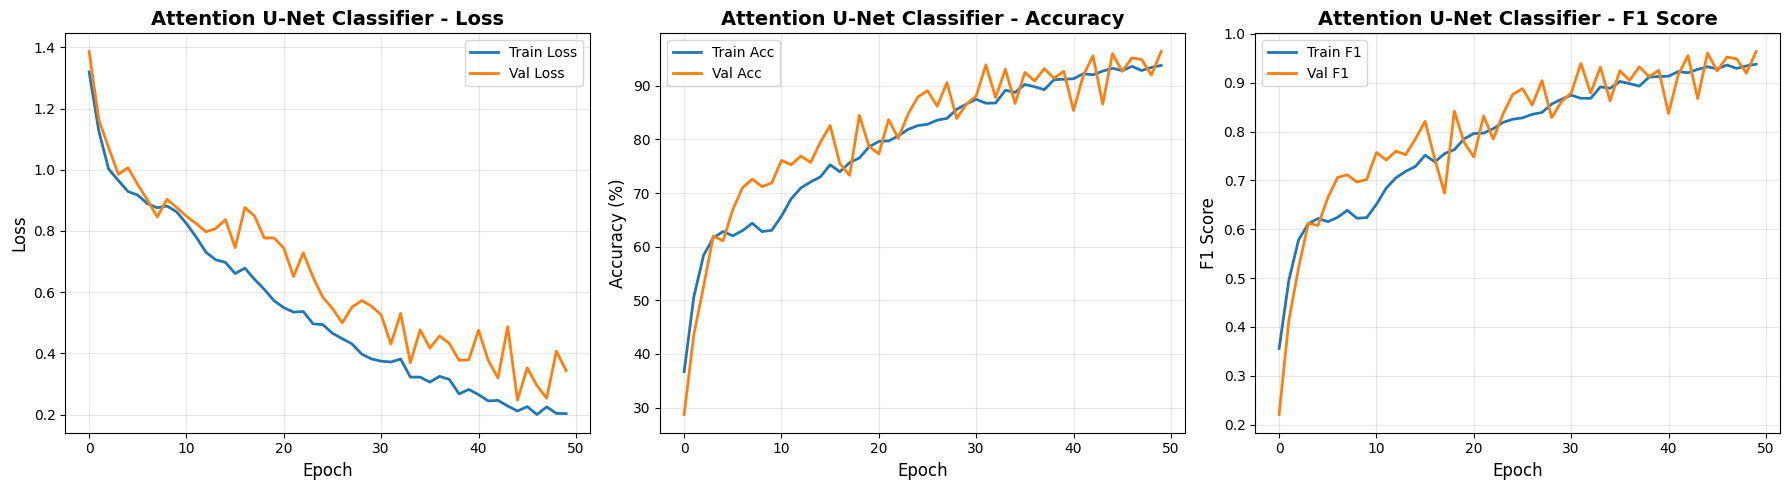

Training plots saved as 'attention_classifier_training.png'


In [73]:
# Plot training history for Attention U-Net Classifier
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(attn_cls_history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(attn_cls_history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Attention U-Net Classifier - Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(attn_cls_history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(attn_cls_history['val_acc'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Attention U-Net Classifier - Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(attn_cls_history['train_f1'], label='Train F1', linewidth=2)
axes[2].plot(attn_cls_history['val_f1'], label='Val F1', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('F1 Score', fontsize=12)
axes[2].set_title('Attention U-Net Classifier - F1 Score', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('attention_classifier_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training plots saved as 'attention_classifier_training.png'")

In [74]:
# Evaluate Attention U-Net Classifier on all splits
print("="*60)
print("Evaluating Attention U-Net Classifier")
print("="*60)

# Load best model
attention_classifier.load_state_dict(torch.load('attention_classifier_best.pth'))

attn_cls_results = {}
for split_name, loader in [('Train', cls_train_loader), ('Val', cls_val_loader), ('Test', cls_test_loader)]:
    # evaluate_cls returns (metrics, confusion_matrix) and needs split_name parameter
    metrics, cm = evaluate_cls(attention_unet_loaded, attention_classifier, loader, config.DEVICE, split_name)
    attn_cls_results[split_name] = metrics
    
    print(f"\n{split_name} Set:")
    print(f"  Accuracy:  {metrics['acc'] * 100:.2f}%")  # 'acc' not 'accuracy'
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1 Score:  {metrics['f1']:.4f}")

# Save results
attn_cls_df = pd.DataFrame(attn_cls_results).T
attn_cls_df.to_csv('attention_classifier_results.csv')
print(f"\nResults saved to 'attention_classifier_results.csv'")
print("="*60)

Evaluating Attention U-Net Classifier



Train Set:
  Accuracy:  96.97%
  Precision: 0.9701
  Recall:    0.9689
  F1 Score:  0.9690



Val Set:
  Accuracy:  96.40%
  Precision: 0.9644
  Recall:    0.9639
  F1 Score:  0.9639



Test Set:
  Accuracy:  95.60%
  Precision: 0.9556
  Recall:    0.9585
  F1 Score:  0.9563

Results saved to 'attention_classifier_results.csv'


In [75]:
# Compare Regular U-Net Classifier vs Attention U-Net Classifier
print("\n" + "="*80)
print("CLASSIFIER COMPARISON: U-Net Encoder vs Attention U-Net Encoder")
print("="*80)

# Load regular classifier results for comparison
try:
    regular_cls_df = pd.read_csv('classification_results.csv', index_col=0)
    
    # Note: regular_cls_df has lowercase index ('test') and capitalized columns ('Accuracy', 'Precision', etc.)
    # attn_cls_df has capitalized index ('Test') and lowercase columns ('acc', 'precision', etc.)
    
    comparison_data = {
        'Metric': ['Accuracy (%)', 'Precision', 'Recall', 'F1 Score'],
        'U-Net (Test)': [
            regular_cls_df.loc['test', 'Accuracy'],    # Capitalized column name, lowercase index
            regular_cls_df.loc['test', 'Precision'],
            regular_cls_df.loc['test', 'Recall'],
            regular_cls_df.loc['test', 'F1']
        ],
        'Attention U-Net (Test)': [
            attn_cls_df.loc['Test', 'acc'],           # lowercase column name, capitalized index
            attn_cls_df.loc['Test', 'precision'],
            attn_cls_df.loc['Test', 'recall'],
            attn_cls_df.loc['Test', 'f1']
        ]
    }
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df['Improvement'] = comparison_df['Attention U-Net (Test)'] - comparison_df['U-Net (Test)']
    
    print(comparison_df.to_string(index=False))
    print("="*80)
    
    # Determine winner
    if attn_cls_df.loc['Test', 'f1'] > regular_cls_df.loc['test', 'F1']:
        print(f"\n✓ Attention U-Net Classifier performs better (F1: {attn_cls_df.loc['Test', 'f1']:.4f} vs {regular_cls_df.loc['test', 'F1']:.4f})")
    else:
        print(f"\n✓ Regular U-Net Classifier performs better (F1: {regular_cls_df.loc['test', 'F1']:.4f} vs {attn_cls_df.loc['Test', 'f1']:.4f})")
    
except FileNotFoundError:
    print("Regular classifier results not found. Run section 7 first to enable comparison.")
    print(f"Attention U-Net Classifier Test F1: {attn_cls_df.loc['Test', 'f1']:.4f}")


CLASSIFIER COMPARISON: U-Net Encoder vs Attention U-Net Encoder
      Metric  U-Net (Test)  Attention U-Net (Test)  Improvement
Accuracy (%)      0.785000                0.956000     0.171000
   Precision      0.822191                0.955617     0.133426
      Recall      0.792305                0.958486     0.166180
    F1 Score      0.785646                0.956283     0.170636

✓ Attention U-Net Classifier performs better (F1: 0.9563 vs 0.7856)


In [76]:
# =============================================================================
# COMPARE U-NET VS ATTENTION U-NET
# =============================================================================

print("="*80)
print("MODEL COMPARISON: U-NET vs ATTENTION U-NET")
print("="*80)

# Load regular U-Net results
unet_df = pd.read_csv('segmentation_results.csv')
attn_df = pd.read_csv('attention_unet_results.csv')

# Merge for comparison
comparison = pd.DataFrame({
    'Split': unet_df['Split'],
    'UNet_Dice': unet_df['Dice'],
    'AttUNet_Dice': attn_df['Dice'],
    'Improvement_Dice': attn_df['Dice'] - unet_df['Dice'],
    'UNet_mIoU': unet_df['mIoU'],
    'AttUNet_mIoU': attn_df['mIoU'],
    'Improvement_mIoU': attn_df['mIoU'] - unet_df['mIoU']
})

print("\n📊 Performance Comparison:")
print(comparison.to_string(index=False))

# Summary
print(f"\n📈 Overall Improvement:")
avg_dice_improvement = comparison['Improvement_Dice'].mean()
avg_miou_improvement = comparison['Improvement_mIoU'].mean()

print(f"  Average Dice improvement: {avg_dice_improvement:+.4f}")
print(f"  Average mIoU improvement: {avg_miou_improvement:+.4f}")

if avg_dice_improvement > 0:
    print(f"\n✅ Attention U-Net performs BETTER than regular U-Net")
else:
    print(f"\n⚠️ Regular U-Net performs better (attention may need more epochs)")

print("="*80)

MODEL COMPARISON: U-NET vs ATTENTION U-NET

📊 Performance Comparison:
Split  UNet_Dice  AttUNet_Dice  Improvement_Dice  UNet_mIoU  AttUNet_mIoU  Improvement_mIoU
train   0.883480      0.890082          0.006602   0.793509      0.803823          0.010314
  val   0.851119      0.858775          0.007656   0.745174      0.756463          0.011289
 test   0.855262      0.856155          0.000893   0.755061      0.756968          0.001908

📈 Overall Improvement:
  Average Dice improvement: +0.0051
  Average mIoU improvement: +0.0078

✅ Attention U-Net performs BETTER than regular U-Net


In [77]:
# =============================================================================
# PROJECT SUMMARY
# =============================================================================

import os

print("="*80)
print("PROJECT SUMMARY")
print("="*80)

print("\n DATASETS:")
print(f"  Segmentation:")
print(f"    Train:  {len(seg_train_dataset)} images")
print(f"    Val:    {len(seg_val_dataset)} images")
print(f"    Test:   {len(seg_test_dataset)} images")
print(f"  Classification:")
print(f"    Train:  {len(cls_train_dataset)} images")
print(f"    Val:    {len(cls_val_dataset)} images")
print(f"    Test:   {len(cls_test_dataset)} images")

print("\n MODEL ARCHITECTURE:")
print(f"  Input: Grayscale ({config.IN_CHANNELS} channel)")
print(f"  Encoder: 5 levels")
print(f"  Segmentation head: Conv → sigmoid")
print(f"  Classification head: GAP → MLP (4 classes)")
print(f"  Total parameters: {total_params:,}")

print("\n TRAINING:")
print(f"  Stage 1 (Segmentation):")
print(f"    Epochs: {config.NUM_EPOCHS}")
print(f"    Best Dice: {best_dice:.4f}")
print(f"  Stage 2 (Classification):")
print(f"    Epochs: {config.NUM_EPOCHS}")
print(f"    Best F1: {best_f1:.4f}")

print("\n OUTPUT FILES:")
files = [
    'unet_seg_best.pth',
    'attention_unet_seg_best.pth',
    'classifier_best.pth',
    'attention_classifier_best.pth',
    'segmentation_results.csv',
    'attention_unet_results.csv',
    'classification_results.csv',
    'attention_classifier_results.csv'
]

for fname in files:
    exists = os.path.exists(fname)
    status = "✓" if exists else "❌"
    print(f"  {status} {fname}")

print("="*80)

print(" NOTEBOOK EXECUTION COMPLETE!")
print("="*80)

PROJECT SUMMARY

 DATASETS:
  Segmentation:
    Train:  3146 images
    Val:    787 images
    Test:   860 images
  Classification:
    Train:  4000 images
    Val:    1000 images
    Test:   1000 images

 MODEL ARCHITECTURE:
  Input: Grayscale (1 channel)
  Encoder: 5 levels
  Segmentation head: Conv → sigmoid
  Classification head: GAP → MLP (4 classes)
  Total parameters: 31,388,078

 TRAINING:
  Stage 1 (Segmentation):
    Epochs: 50
    Best Dice: 0.8511
  Stage 2 (Classification):
    Epochs: 50
    Best F1: 0.8041

 OUTPUT FILES:
  ✓ unet_seg_best.pth
  ✓ attention_unet_seg_best.pth
  ✓ classifier_best.pth
  ✓ attention_classifier_best.pth
  ✓ segmentation_results.csv
  ✓ attention_unet_results.csv
  ✓ classification_results.csv
  ✓ attention_classifier_results.csv
 NOTEBOOK EXECUTION COMPLETE!


## 12) PROJECT SUMMARY & COMPARISON

Final comparison and project overview:
- 📊 Compare U-Net vs Attention U-Net performance
- 📈 Segmentation metrics (Dice, mIoU improvement)
- 🏆 Classification metrics (Regular vs Attention features)
- 📁 Generated artifacts and checkpoints summary

## 9) DEMO FUNCTIONS

### 9.1 Demo with U-Net + Classifier

In [78]:
# =============================================================================
# DEMO FUNCTION: U-Net + MobileNet Classifier
# =============================================================================

def demo_image_unet(image_path):
    """
    6-Panel visualization for ANY input image using U-Net
    
    Args:
        image_path: Path to ANY brain MRI image (str)
    
    Panels:
        1. Original Image
        2. Ground Truth Mask (if available)
        3. Ground Truth Overlay (Yellow)
        4. Processed Image (after augmentations)
        5. Predicted Mask
        6. Predicted Overlay (Green)
    
    Returns:
        dict: Prediction results including class, confidence, tumor coverage
    """
    # Load models
    unet_model = UNet(
        in_channels=config.IN_CHANNELS,
        num_classes=config.NUM_CLASSES_SEG,
        base_channels=config.BASE_CHANNELS
    ).to(config.DEVICE)
    
    classifier_model = classifierhead(
        encoder_channels=config.BASE_CHANNELS * 16,
        num_classes=config.NUM_CLASSES_CLASSIFY
    ).to(config.DEVICE)
    
    # Load checkpoints
    unet_checkpoint = torch.load('unet_seg_best.pth')
    unet_model.load_state_dict(unet_checkpoint['model_state_dict'])
    unet_model.eval()
    
    classifier_checkpoint = torch.load('classifier_best.pth')
    classifier_model.load_state_dict(classifier_checkpoint['model_state_dict'])
    classifier_model.eval()
    
    # Load original image
    orig_img = cv2.imread(image_path)
    if orig_img is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    img_name = os.path.basename(image_path)
    orig_display = orig_img / 255.0
    
    # Try to find ground truth mask
    parts = img_name.split('_')
    ground_truth_mask = None
    mask_found = False
    
    if len(parts) >= 3:
        img_id = parts[2]
        
        # Search in test masks
        if os.path.exists(config.SEG_TEST_MASK):
            all_masks = [f for f in os.listdir(config.SEG_TEST_MASK) if f.endswith(('.jpg', '.png', '.jpeg'))]
            for mask_file in all_masks:
                mask_parts = mask_file.split('_')
                if len(mask_parts) >= 3 and mask_parts[2] == img_id:
                    mask_path = os.path.join(config.SEG_TEST_MASK, mask_file)
                    ground_truth_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if ground_truth_mask is not None:
                        ground_truth_mask = (ground_truth_mask > 127).astype(np.float32)
                        mask_found = True
                    break
        
        # Search in train masks
        if not mask_found and os.path.exists(config.SEG_TRAIN_MASK):
            all_masks = [f for f in os.listdir(config.SEG_TRAIN_MASK) if f.endswith(('.jpg', '.png', '.jpeg'))]
            for mask_file in all_masks:
                mask_parts = mask_file.split('_')
                if len(mask_parts) >= 3 and mask_parts[2] == img_id:
                    mask_path = os.path.join(config.SEG_TRAIN_MASK, mask_file)
                    ground_truth_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if ground_truth_mask is not None:
                        ground_truth_mask = (ground_truth_mask > 127).astype(np.float32)
                        mask_found = True
                    break
    
    # Preprocess image
    transform = A.Compose([
        A.Resize(config.IMAGE_SIZE, config.IMAGE_SIZE),
        A.Normalize(mean=[dataset_mean], std=[dataset_std]),
        ToTensorV2()
    ])
    
    augmented = transform(image=cv2.cvtColor(orig_img, cv2.COLOR_RGB2GRAY))
    proc_img = augmented['image'].unsqueeze(0)  # Add channel dimension
    
    # Denormalize for display
    proc_display = proc_img.squeeze(0).permute(1, 2, 0).numpy()
    proc_display = proc_display * dataset_std + dataset_mean
    proc_display = np.clip(proc_display, 0, 1)
    proc_display = np.repeat(proc_display, 3, axis=2)  # Convert to RGB for display
    
    # Get predictions
    with torch.no_grad():
        img_tensor = proc_img.to(config.DEVICE)
        
        # Segmentation
        seg_output = unet_model(img_tensor)
        # Handle 2-channel output by taking first channel only
        if seg_output.shape[1] == 2:
            seg_output = seg_output[:, 1:2, :]
        pred_mask = torch.sigmoid(seg_output).cpu().squeeze().numpy()
        pred_mask_binary = (pred_mask > 0.5).astype(np.float32)
        
        # Classification (using encoder features)
        encoder_features = unet_model.get_encoder_features(img_tensor)
        class_output = classifier_model(encoder_features)
        class_probs = torch.softmax(class_output, dim=1).cpu().squeeze().numpy()
        class_pred = np.argmax(class_probs)
        class_name = config.CLASS_NAMES[class_pred]
        confidence = class_probs[class_pred] * 100
    
    # Calculate tumor coverage
    tumor_pixels = np.sum(pred_mask_binary > 0.5)
    total_pixels = pred_mask_binary.size
    tumor_percentage = 100 * tumor_pixels / total_pixels
    
    # Create 6-panel visualization
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # Panel 1: Original Image
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(orig_display)
    ax1.set_title('1. Original Image', fontsize=13, fontweight='bold', color='white',
                  bbox=dict(boxstyle='round', facecolor='#2E86AB', alpha=0.9, pad=0.5))
    ax1.axis('off')
    
    # Panel 2: Ground Truth Mask
    ax2 = fig.add_subplot(gs[0, 1])
    if mask_found:
        ax2.imshow(ground_truth_mask, cmap='gray', vmin=0, vmax=1)
        gt_tumor_percentage = 100 * np.sum(ground_truth_mask > 0.5) / ground_truth_mask.size
        ax2.set_title(f'2. Ground Truth Mask\\nCoverage: {gt_tumor_percentage:.1f}%',
                      fontsize=13, fontweight='bold', color='white',
                      bbox=dict(boxstyle='round', facecolor='#F18F01', alpha=0.9, pad=0.5))
    else:
        ax2.text(0.5, 0.5, 'Ground Truth\\nNot Available', ha='center', va='center',
                fontsize=14, fontweight='bold', color='red',
                transform=ax2.transAxes)
        ax2.set_title('2. Ground Truth Mask',
                      fontsize=13, fontweight='bold', color='white',
                      bbox=dict(boxstyle='round', facecolor='#F18F01', alpha=0.9, pad=0.5))
    ax2.axis('off')
    
    # Panel 3: Ground Truth Overlay
    ax3 = fig.add_subplot(gs[0, 2])
    if mask_found:
        overlay_gt = orig_display.copy()
        orig_h, orig_w = overlay_gt.shape[:2]
        gt_mask_resized = cv2.resize(ground_truth_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
        
        mask_overlay_gt = np.zeros_like(overlay_gt)
        mask_overlay_gt[gt_mask_resized > 0.5] = [1, 1, 0]  # Yellow
        overlay_gt = overlay_gt * 0.6 + mask_overlay_gt * 0.4
        ax3.imshow(overlay_gt)
        ax3.set_title('3. Ground Truth Overlay\\n(Yellow = True Tumor)',
                      fontsize=13, fontweight='bold', color='white',
                      bbox=dict(boxstyle='round', facecolor='#6A4C93', alpha=0.9, pad=0.5))
    else:
        ax3.imshow(orig_display)
        ax3.text(0.5, 0.5, 'Ground Truth\\nOverlay\\nNot Available', ha='center', va='center',
                fontsize=12, fontweight='bold', color='red',
                transform=ax3.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, pad=0.5))
        ax3.set_title('3. Ground Truth Overlay',
                      fontsize=13, fontweight='bold', color='white',
                      bbox=dict(boxstyle='round', facecolor='#6A4C93', alpha=0.9, pad=0.5))
    ax3.axis('off')
    
    # Panel 4: Processed Image
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.imshow(proc_display, cmap='gray')
    ax4.set_title('4. Processed Image\\n(After Augmentations)',
                  fontsize=13, fontweight='bold', color='white',
                  bbox=dict(boxstyle='round', facecolor='#2D6A4F', alpha=0.9, pad=0.5))
    ax4.axis('off')
    
    # Panel 5: Predicted Mask
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.imshow(pred_mask_binary, cmap='gray', vmin=0, vmax=1)
    ax5.set_title(f'5. Predicted Mask\\nCoverage: {tumor_percentage:.1f}%',
                  fontsize=13, fontweight='bold', color='white',
                  bbox=dict(boxstyle='round', facecolor='#C9184A', alpha=0.9, pad=0.5))
    ax5.axis('off')
    
    # Panel 6: Predicted Overlay
    ax6 = fig.add_subplot(gs[1, 2])
    overlay_pred = orig_display.copy()
    orig_h, orig_w = overlay_pred.shape[:2]
    pred_mask_resized = cv2.resize(pred_mask_binary, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    
    mask_overlay_pred = np.zeros_like(overlay_pred)
    mask_overlay_pred[pred_mask_resized > 0.5] = [0, 1, 0]  # Green
    overlay_pred = overlay_pred * 0.6 + mask_overlay_pred * 0.4
    ax6.imshow(overlay_pred)
    ax6.set_title('6. Predicted Overlay\\n(Green = Predicted Tumor)',
                  fontsize=13, fontweight='bold', color='white',
                  bbox=dict(boxstyle='round', facecolor='#FF6B35', alpha=0.9, pad=0.5))
    ax6.axis('off')
    
    # Overall title
    plt.suptitle(f'U-Net Analysis: {img_name}\\nClassification: {class_name.upper()} (Confidence: {confidence:.1f}%)',
                fontsize=16, fontweight='bold', y=0.98,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3, pad=1.0))
    
    plt.savefig(os.path.join(config.PLOT_DIR, f'unet_demo_{img_name}'),
               dpi=200, bbox_inches='tight')
    plt.show()
    
    # Print results
    print(f"\\n{'='*70}")
    print(f"U-NET RESULTS FOR: {img_name}")
    print(f"{'='*70}")
    print(f"\\nClassification: {class_name.upper()} ({confidence:.2f}% confidence)")
    print(f"Predicted Tumor Coverage: {tumor_percentage:.2f}%")
    if mask_found:
        print(f"Ground Truth Tumor Coverage: {gt_tumor_percentage:.2f}%")
        print(f"Coverage Difference: {abs(tumor_percentage - gt_tumor_percentage):.2f}%")
    print(f"\\nClass Probabilities:")
    for cls, prob in zip(config.CLASS_NAMES, class_probs):
        print(f"  {cls:15s}: {prob*100:6.2f}%")
    print(f"{'='*70}\\n")
    
    return {
        'model': 'U-Net',
        'predicted_class': class_name,
        'confidence': confidence,
        'tumor_percentage': tumor_percentage,
        'mask': pred_mask_binary,
        'probabilities': dict(zip(config.CLASS_NAMES, class_probs)),
        'ground_truth_found': mask_found
    }

print("  Usage: demo_image_unet('path/to/image.jpg')")
print("✓ U-Net demo function loaded!")

  Usage: demo_image_unet('path/to/image.jpg')
✓ U-Net demo function loaded!


### 9.2 Demo with Attention U-Net + Classifier

In [79]:
# =============================================================================
# DEMO FUNCTION: Attention U-Net + MobileNet Classifier
# =============================================================================

def demo_image_attention_unet(image_path):
    """
    6-Panel visualization for ANY input image using Attention U-Net
    
    Args:
        image_path: Path to ANY brain MRI image (str)
    
    Panels:
        1. Original Image
        2. Ground Truth Mask (if available)
        3. Ground Truth Overlay (Yellow)
        4. Processed Image (after augmentations)
        5. Predicted Mask
        6. Predicted Overlay (Green)
    
    Returns:
        dict: Prediction results including class, confidence, tumor coverage
    """
    # Load models
    attention_unet_model = AttentionUNet(
        in_channels=config.IN_CHANNELS,
        num_classes=config.NUM_CLASSES_SEG,
        base_channels=config.BASE_CHANNELS
    ).to(config.DEVICE)
    
    classifier_model = classifierhead(
        encoder_channels=config.BASE_CHANNELS * 16,
        num_classes=config.NUM_CLASSES_CLASSIFY
    ).to(config.DEVICE)
    
    # Load checkpoints
    attention_checkpoint = torch.load('attention_unet_seg_best.pth')
    attention_unet_model.load_state_dict(attention_checkpoint['model_state_dict'])
    attention_unet_model.eval()
    
    # Attention classifier is saved directly as state_dict, not in a dictionary
    classifier_checkpoint = torch.load('attention_classifier_best.pth')
    classifier_model.load_state_dict(classifier_checkpoint)
    classifier_model.eval()
    
    # Load original image
    orig_img = cv2.imread(image_path)
    if orig_img is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    img_name = os.path.basename(image_path)
    orig_display = orig_img / 255.0
    
    # Try to find ground truth mask
    parts = img_name.split('_')
    ground_truth_mask = None
    mask_found = False
    
    if len(parts) >= 3:
        img_id = parts[2]
        
        # Search in test masks
        if os.path.exists(config.SEG_TEST_MASK):
            all_masks = [f for f in os.listdir(config.SEG_TEST_MASK) if f.endswith(('.jpg', '.png', '.jpeg'))]
            for mask_file in all_masks:
                mask_parts = mask_file.split('_')
                if len(mask_parts) >= 3 and mask_parts[2] == img_id:
                    mask_path = os.path.join(config.SEG_TEST_MASK, mask_file)
                    ground_truth_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if ground_truth_mask is not None:
                        ground_truth_mask = (ground_truth_mask > 127).astype(np.float32)
                        mask_found = True
                    break
        
        # Search in train masks
        if not mask_found and os.path.exists(config.SEG_TRAIN_MASK):
            all_masks = [f for f in os.listdir(config.SEG_TRAIN_MASK) if f.endswith(('.jpg', '.png', '.jpeg'))]
            for mask_file in all_masks:
                mask_parts = mask_file.split('_')
                if len(mask_parts) >= 3 and mask_parts[2] == img_id:
                    mask_path = os.path.join(config.SEG_TRAIN_MASK, mask_file)
                    ground_truth_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if ground_truth_mask is not None:
                        ground_truth_mask = (ground_truth_mask > 127).astype(np.float32)
                        mask_found = True
                    break
    
    # Preprocess image
    transform = A.Compose([
        A.Resize(config.IMAGE_SIZE, config.IMAGE_SIZE),
        A.Normalize(mean=[dataset_mean], std=[dataset_std]),
        ToTensorV2()
    ])
    
    augmented = transform(image=cv2.cvtColor(orig_img, cv2.COLOR_RGB2GRAY))
    proc_img = augmented['image'].unsqueeze(0)  # Add channel dimension
    
    # Denormalize for display
    proc_display = proc_img.squeeze(0).permute(1, 2, 0).numpy()
    proc_display = proc_display * dataset_std + dataset_mean
    proc_display = np.clip(proc_display, 0, 1)
    proc_display = np.repeat(proc_display, 3, axis=2)  # Convert to RGB for display
    
    # Get predictions
    with torch.no_grad():
        img_tensor = proc_img.to(config.DEVICE)
        
        # Segmentation
        seg_output = attention_unet_model(img_tensor)
        # Handle 2-channel output by taking first channel only
        if seg_output.shape[1] == 2:
            seg_output = seg_output[:, 1:2, :]
        pred_mask = torch.sigmoid(seg_output).cpu().squeeze().numpy()
        pred_mask_binary = (pred_mask > 0.5).astype(np.float32)
        
        # Classification (using encoder features)
        encoder_features = attention_unet_model.get_encoder_features(img_tensor)
        class_output = classifier_model(encoder_features)
        class_probs = torch.softmax(class_output, dim=1).cpu().squeeze().numpy()
        class_pred = np.argmax(class_probs)
        class_name = config.CLASS_NAMES[class_pred]
        confidence = class_probs[class_pred] * 100
    
    # Calculate tumor coverage
    tumor_pixels = np.sum(pred_mask_binary > 0.5)
    total_pixels = pred_mask_binary.size
    tumor_percentage = 100 * tumor_pixels / total_pixels
    
    # Create 6-panel visualization
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # Panel 1: Original Image
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(orig_display)
    ax1.set_title('1. Original Image', fontsize=13, fontweight='bold', color='white',
                  bbox=dict(boxstyle='round', facecolor='#2E86AB', alpha=0.9, pad=0.5))
    ax1.axis('off')
    
    # Panel 2: Ground Truth Mask
    ax2 = fig.add_subplot(gs[0, 1])
    if mask_found:
        ax2.imshow(ground_truth_mask, cmap='gray', vmin=0, vmax=1)
        gt_tumor_percentage = 100 * np.sum(ground_truth_mask > 0.5) / ground_truth_mask.size
        ax2.set_title(f'2. Ground Truth Mask\\nCoverage: {gt_tumor_percentage:.1f}%',
                      fontsize=13, fontweight='bold', color='white',
                      bbox=dict(boxstyle='round', facecolor='#F18F01', alpha=0.9, pad=0.5))
    else:
        ax2.text(0.5, 0.5, 'Ground Truth\\nNot Available', ha='center', va='center',
                fontsize=14, fontweight='bold', color='red',
                transform=ax2.transAxes)
        ax2.set_title('2. Ground Truth Mask',
                      fontsize=13, fontweight='bold', color='white',
                      bbox=dict(boxstyle='round', facecolor='#F18F01', alpha=0.9, pad=0.5))
    ax2.axis('off')
    
    # Panel 3: Ground Truth Overlay
    ax3 = fig.add_subplot(gs[0, 2])
    if mask_found:
        overlay_gt = orig_display.copy()
        orig_h, orig_w = overlay_gt.shape[:2]
        gt_mask_resized = cv2.resize(ground_truth_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
        
        mask_overlay_gt = np.zeros_like(overlay_gt)
        mask_overlay_gt[gt_mask_resized > 0.5] = [1, 1, 0]  # Yellow
        overlay_gt = overlay_gt * 0.6 + mask_overlay_gt * 0.4
        ax3.imshow(overlay_gt)
        ax3.set_title('3. Ground Truth Overlay\\n(Yellow = True Tumor)',
                      fontsize=13, fontweight='bold', color='white',
                      bbox=dict(boxstyle='round', facecolor='#6A4C93', alpha=0.9, pad=0.5))
    else:
        ax3.imshow(orig_display)
        ax3.text(0.5, 0.5, 'Ground Truth\\nOverlay\\nNot Available', ha='center', va='center',
                fontsize=12, fontweight='bold', color='red',
                transform=ax3.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, pad=0.5))
        ax3.set_title('3. Ground Truth Overlay',
                      fontsize=13, fontweight='bold', color='white',
                      bbox=dict(boxstyle='round', facecolor='#6A4C93', alpha=0.9, pad=0.5))
    ax3.axis('off')
    
    # Panel 4: Processed Image
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.imshow(proc_display, cmap='gray')
    ax4.set_title('4. Processed Image\\n(After Augmentations)',
                  fontsize=13, fontweight='bold', color='white',
                  bbox=dict(boxstyle='round', facecolor='#2D6A4F', alpha=0.9, pad=0.5))
    ax4.axis('off')
    
    # Panel 5: Predicted Mask
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.imshow(pred_mask_binary, cmap='gray', vmin=0, vmax=1)
    ax5.set_title(f'5. Predicted Mask\\nCoverage: {tumor_percentage:.1f}%',
                  fontsize=13, fontweight='bold', color='white',
                  bbox=dict(boxstyle='round', facecolor='#C9184A', alpha=0.9, pad=0.5))
    ax5.axis('off')
    
    # Panel 6: Predicted Overlay
    ax6 = fig.add_subplot(gs[1, 2])
    overlay_pred = orig_display.copy()
    orig_h, orig_w = overlay_pred.shape[:2]
    pred_mask_resized = cv2.resize(pred_mask_binary, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    
    mask_overlay_pred = np.zeros_like(overlay_pred)
    mask_overlay_pred[pred_mask_resized > 0.5] = [0, 1, 0]  # Green
    overlay_pred = overlay_pred * 0.6 + mask_overlay_pred * 0.4
    ax6.imshow(overlay_pred)
    ax6.set_title('6. Predicted Overlay\\n(Green = Predicted Tumor)',
                  fontsize=13, fontweight='bold', color='white',
                  bbox=dict(boxstyle='round', facecolor='#FF6B35', alpha=0.9, pad=0.5))
    ax6.axis('off')
    
    # Overall title
    plt.suptitle(f'Attention U-Net Analysis: {img_name}\\nClassification: {class_name.upper()} (Confidence: {confidence:.1f}%)',
                fontsize=16, fontweight='bold', y=0.98,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3, pad=1.0))
    
    plt.savefig(os.path.join(config.PLOT_DIR, f'attention_unet_demo_{img_name}'),
               dpi=200, bbox_inches='tight')
    plt.show()
    
    # Print results
    print(f"\\n{'='*70}")
    print(f"ATTENTION U-NET RESULTS FOR: {img_name}")
    print(f"{'='*70}")
    print(f"\\nClassification: {class_name.upper()} ({confidence:.2f}% confidence)")
    print(f"Predicted Tumor Coverage: {tumor_percentage:.2f}%")
    if mask_found:
        print(f"Ground Truth Tumor Coverage: {gt_tumor_percentage:.2f}%")
        print(f"Coverage Difference: {abs(tumor_percentage - gt_tumor_percentage):.2f}%")
    print(f"\\nClass Probabilities:")
    for cls, prob in zip(config.CLASS_NAMES, class_probs):
        print(f"  {cls:15s}: {prob*100:6.2f}%")
    print(f"{'='*70}\\n")
    
    return {
        'model': 'Attention U-Net',
        'predicted_class': class_name,
        'confidence': confidence,
        'tumor_percentage': tumor_percentage,
        'mask': pred_mask_binary,
        'probabilities': dict(zip(config.CLASS_NAMES, class_probs)),
        'ground_truth_found': mask_found
    }

print("  Usage: demo_image_attention_unet('path/to/image.jpg')")
print("✓ Attention U-Net demo function loaded!")

  Usage: demo_image_attention_unet('path/to/image.jpg')
✓ Attention U-Net demo function loaded!


Using segmentation image: C:\Users\T2520744\.cache\kagglehub\datasets\briscdataset\brisc2025\versions\6\brisc2025\segmentation_task\train\images\brisc2025_train_01629_me_co_t1.jpg


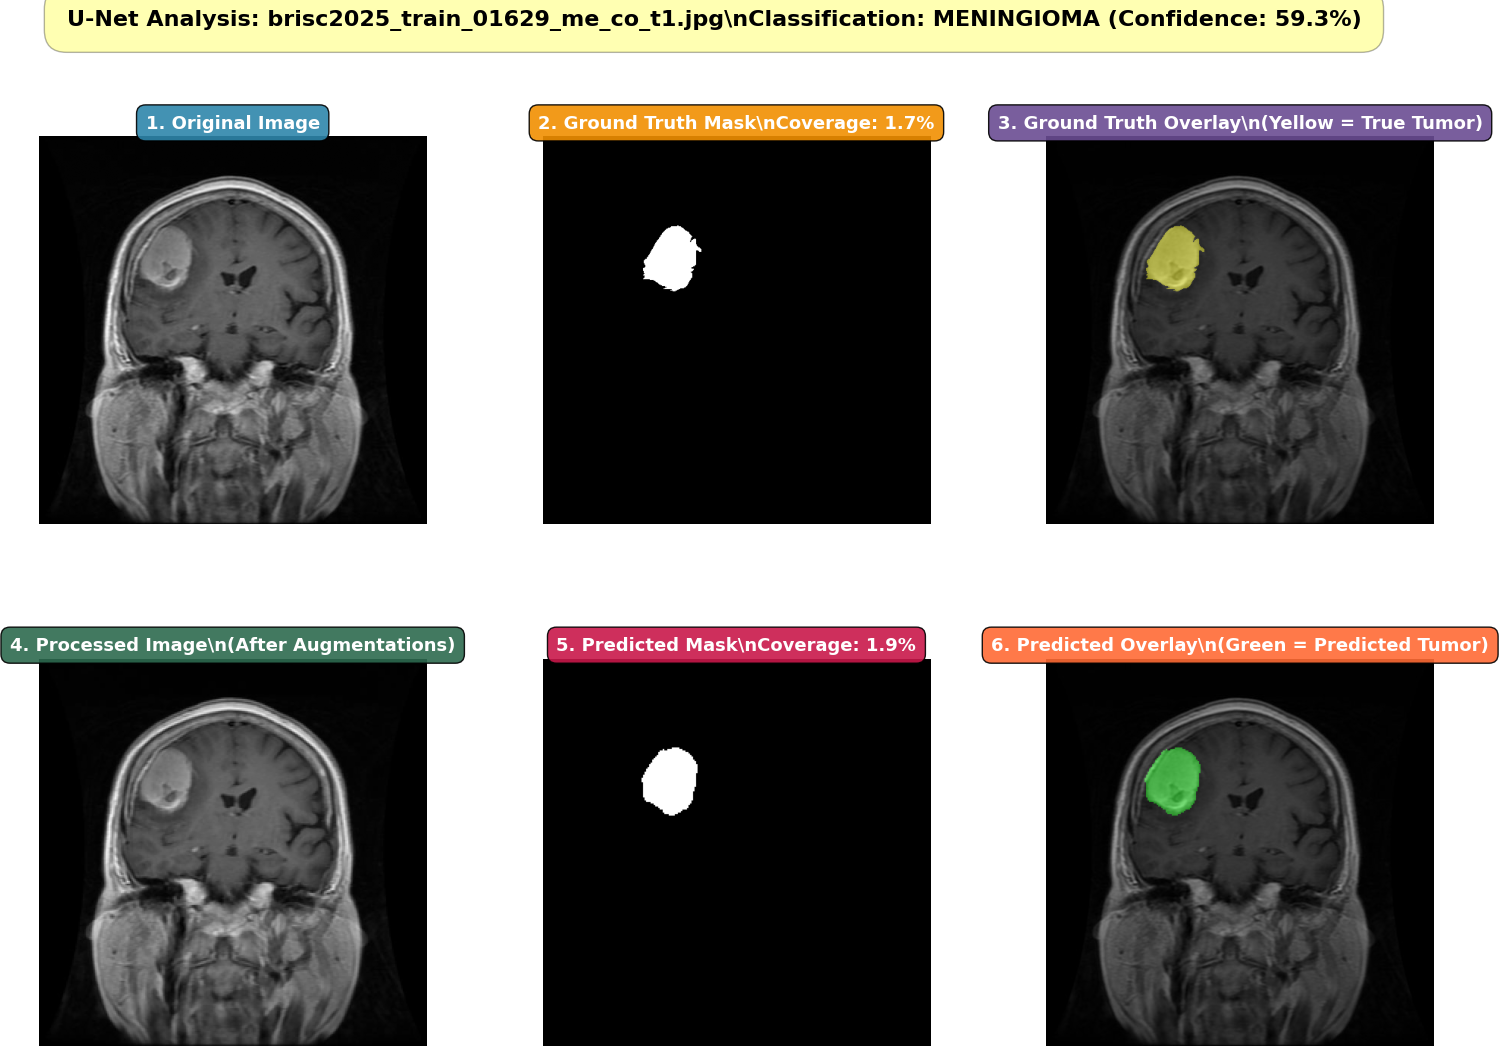

\n======================================================================
U-NET RESULTS FOR: brisc2025_train_01629_me_co_t1.jpg
\nClassification: MENINGIOMA (59.33% confidence)
Predicted Tumor Coverage: 1.88%
Ground Truth Tumor Coverage: 1.66%
Coverage Difference: 0.22%
\nClass Probabilities:
  Glioma         :  19.65%
  Meningioma     :  59.33%
  No Tumor       :  12.26%
  Pituitary      :   8.76%
======================================================================\n


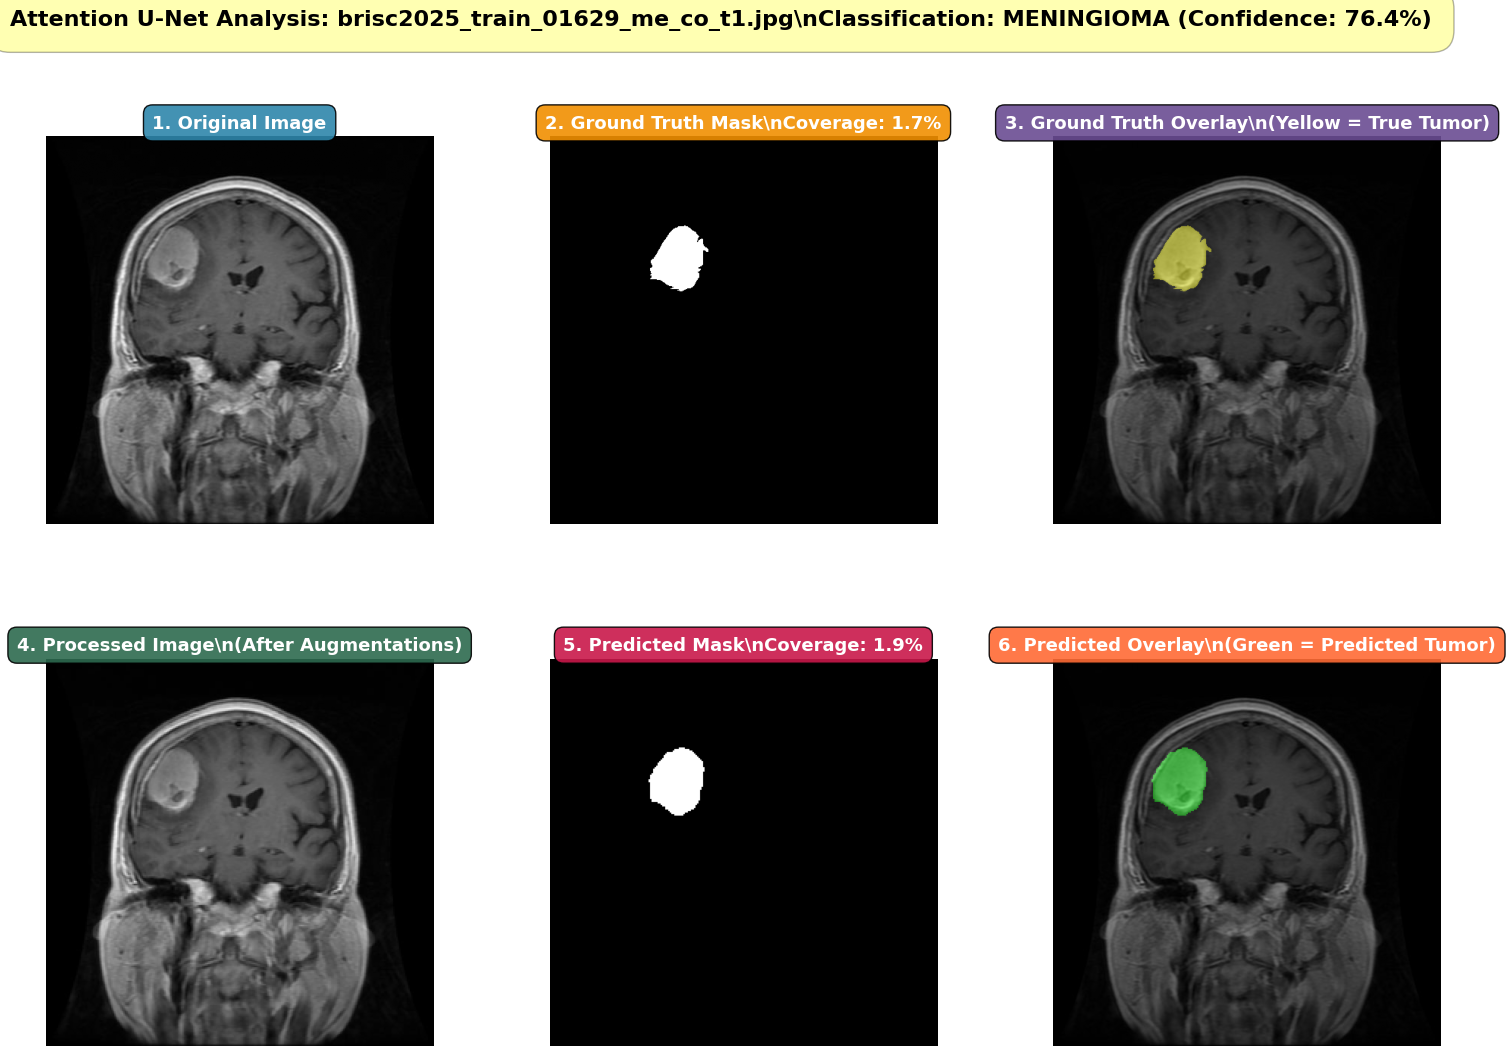

\n======================================================================
ATTENTION U-NET RESULTS FOR: brisc2025_train_01629_me_co_t1.jpg
\nClassification: MENINGIOMA (76.37% confidence)
Predicted Tumor Coverage: 1.85%
Ground Truth Tumor Coverage: 1.66%
Coverage Difference: 0.20%
\nClass Probabilities:
  Glioma         :  15.95%
  Meningioma     :  76.37%
  No Tumor       :   2.53%
  Pituitary      :   5.15%
======================================================================\n


{'model': 'Attention U-Net',
 'predicted_class': 'Meningioma',
 'confidence': np.float32(76.37123),
 'tumor_percentage': np.float64(1.85394287109375),
 'mask': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(256, 256), dtype=float32),
 'probabilities': {'Glioma': np.float32(0.15951791),
  'Meningioma': np.float32(0.7637123),
  'No Tumor': np.float32(0.025272448),
  'Pituitary': np.float32(0.05149739)},
 'ground_truth_found': True}

In [104]:
# Get actual image path from your loaded dataset
sample_seg_path = seg_train_dataset.dataset.image_paths[1628]
print(f"Using segmentation image: {sample_seg_path}")

# Test both models
demo_image_unet(str(sample_seg_path))
demo_image_attention_unet(str(sample_seg_path))

Using classification image: C:\Users\T2520744\.cache\kagglehub\datasets\briscdataset\brisc2025\versions\6\brisc2025\classification_task\train\meningioma\brisc2025_train_01201_me_ax_t1.jpg


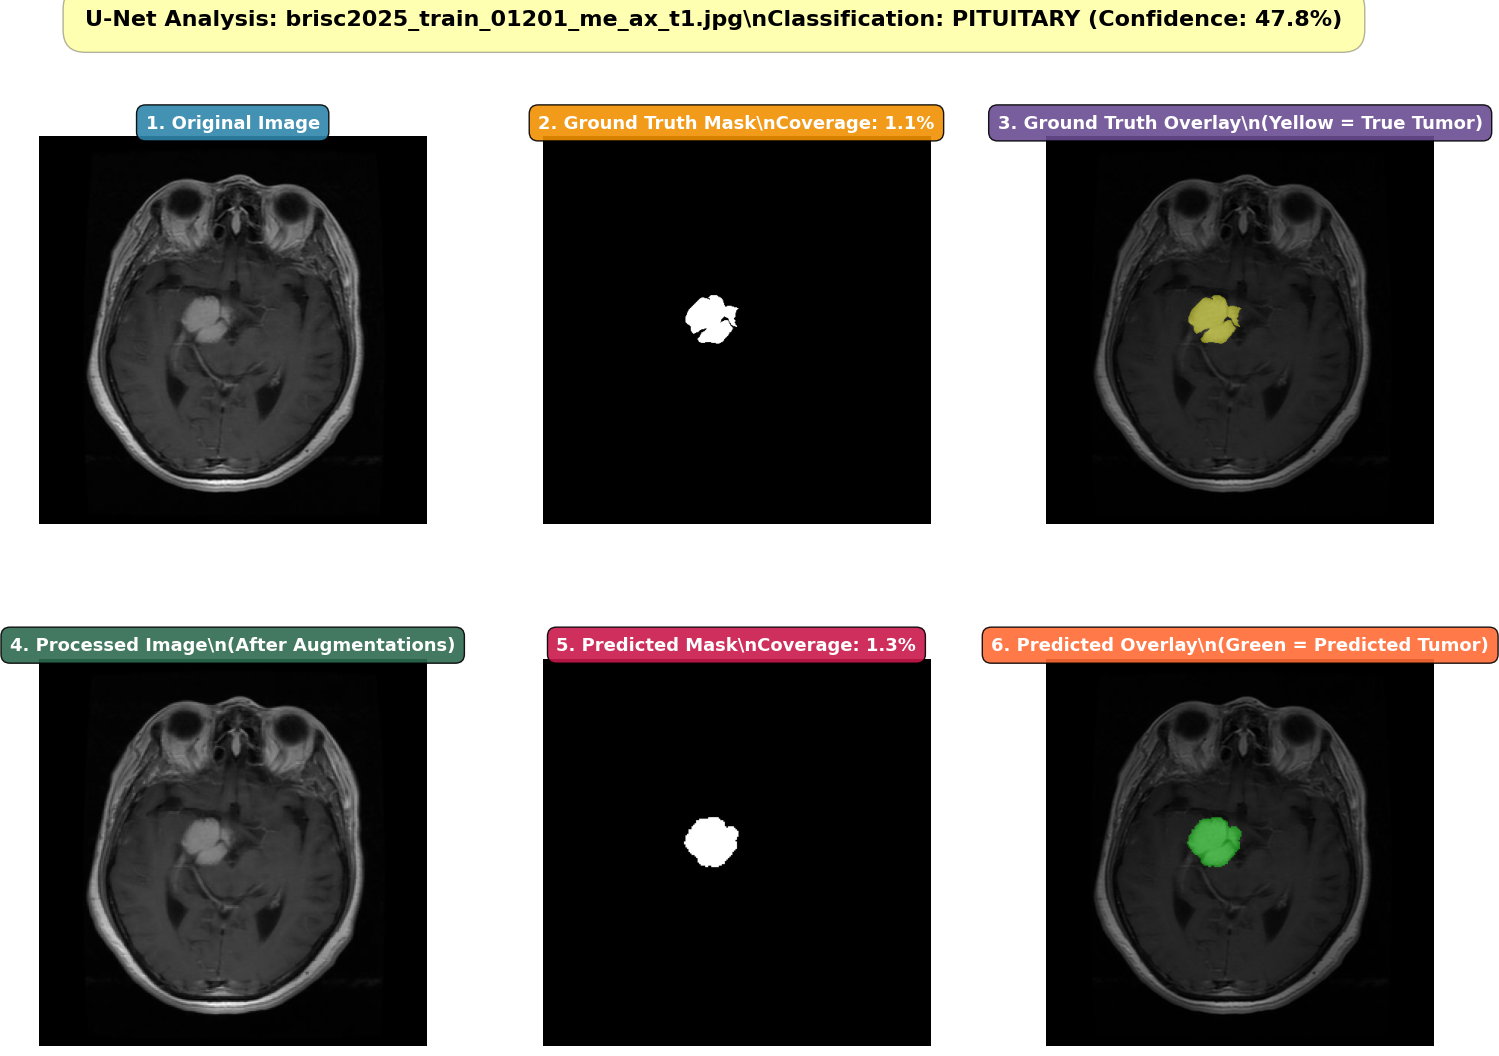

\n======================================================================
U-NET RESULTS FOR: brisc2025_train_01201_me_ax_t1.jpg
\nClassification: PITUITARY (47.85% confidence)
Predicted Tumor Coverage: 1.30%
Ground Truth Tumor Coverage: 1.13%
Coverage Difference: 0.17%
\nClass Probabilities:
  Glioma         :   7.61%
  Meningioma     :  34.39%
  No Tumor       :  10.16%
  Pituitary      :  47.85%
======================================================================\n


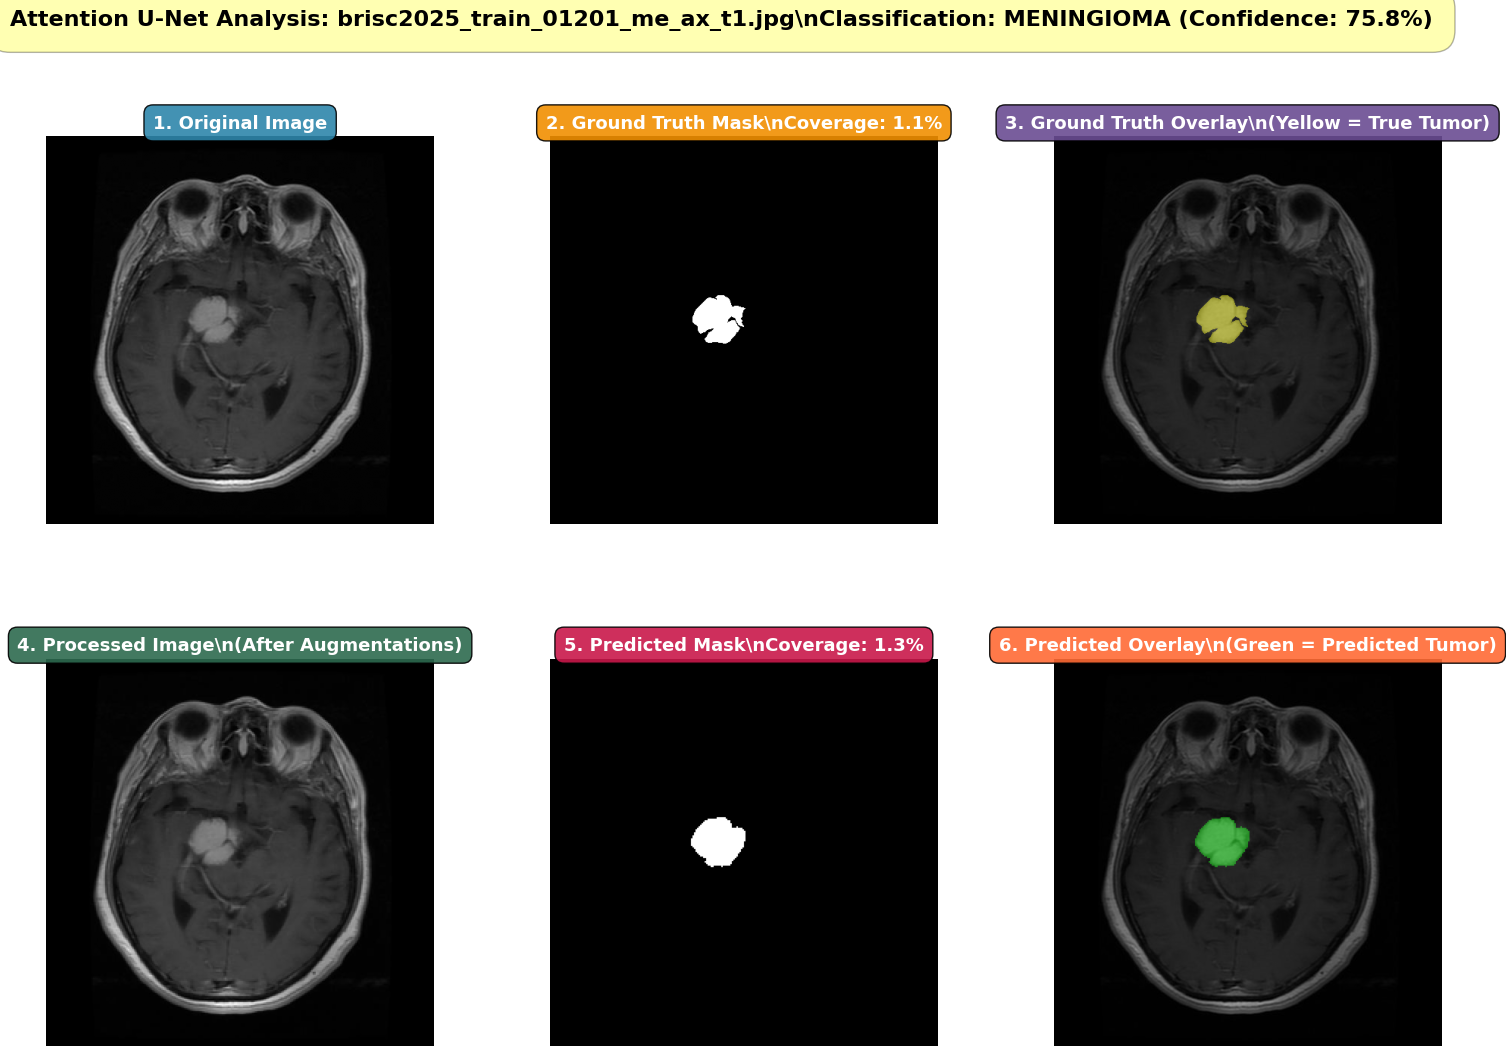

\n======================================================================
ATTENTION U-NET RESULTS FOR: brisc2025_train_01201_me_ax_t1.jpg
\nClassification: MENINGIOMA (75.81% confidence)
Predicted Tumor Coverage: 1.29%
Ground Truth Tumor Coverage: 1.13%
Coverage Difference: 0.16%
\nClass Probabilities:
  Glioma         :  13.90%
  Meningioma     :  75.81%
  No Tumor       :   0.71%
  Pituitary      :   9.59%
======================================================================\n


{'model': 'Attention U-Net',
 'predicted_class': 'Meningioma',
 'confidence': np.float32(75.806496),
 'tumor_percentage': np.float64(1.28936767578125),
 'mask': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(256, 256), dtype=float32),
 'probabilities': {'Glioma': np.float32(0.1389872),
  'Meningioma': np.float32(0.7580649),
  'No Tumor': np.float32(0.0070748962),
  'Pituitary': np.float32(0.09587299)},
 'ground_truth_found': True}

In [110]:
# Get actual classification image path
sample_cls_path = cls_train_images[1200]
print(f"Using classification image: {sample_cls_path}")

# Test both models
demo_image_unet(str(sample_cls_path))
demo_image_attention_unet(str(sample_cls_path))